**Kuchuru Sai Krishna Reddy**

**Final Project Submission**

# Task 1: Data Loading, Feature Engineering and Exploratory Data Analysis

## Objective

The objective of this task is to understand the structure of the Superstore sales dataset, identify data quality issues, engineer time-based features, and perform exploratory data analysis to uncover business insights that will support forecasting and demand analysis in later stages of the project.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

from datetime import datetime

pd.set_option("display.max_columns", None)

plt.style.use("ggplot")

In [2]:
df = pd.read_csv("train.csv")

In [3]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [4]:
print(f"Rows : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

Rows : 9800
Columns : 18


### Observation

The dataset contains the complete Superstore sales records with multiple attributes describing customer details, product information, order information, geographical information, sales, profit, and shipping details. This dataset is suitable for performing exploratory analysis and time series forecasting.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

### Observation

The dataset contains a combination of numerical, categorical, and date-related variables. The data types will be verified and date columns will be converted into datetime format before performing time series analysis.

In [6]:
df.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [7]:
df.describe(include="object")

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Region,Product ID,Category,Sub-Category,Product Name
count,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800
unique,4922,1230,1326,4,793,793,3,1,529,49,4,1861,3,17,1849
top,CA-2018-100111,05/09/2017,26/09/2018,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,California,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope
freq,14,38,34,5859,35,35,5101,9800,891,1946,3140,19,5909,1492,47


### Observation

The statistical summary provides an overview of the numerical variables such as Sales, Quantity, Discount, and Profit. These statistics help identify the spread of the data, possible outliers, and the overall distribution of business metrics.

In [8]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


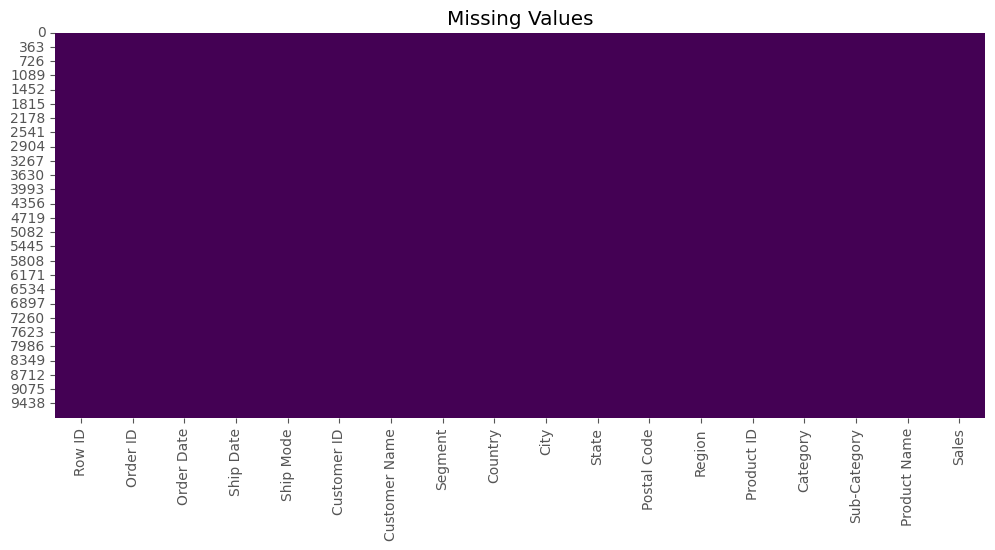

In [9]:
plt.figure(figsize=(12,5))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values")
plt.show()

### Observation

The dataset was examined for missing values to ensure data quality before analysis. Any missing observations will be handled appropriately if detected.

In [10]:
print("Duplicate Records:", df.duplicated().sum())

Duplicate Records: 0


### Observation

Duplicate records were checked to prevent biased analysis and incorrect forecasting results.

In [11]:
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)

In [12]:
df[["Order Date", "Ship Date"]].head()

,Order Date,Ship Date
0,2017-11-08,2017-11-11
1,2017-11-08,2017-11-11
2,2017-06-12,2017-06-16
3,2016-10-11,2016-10-18
4,2016-10-11,2016-10-18


## Feature Engineering

Time-based features were extracted from the `Order Date` column to support exploratory analysis and forecasting. These features help identify yearly trends, monthly seasonality, weekly patterns, and quarterly sales behavior.


In [13]:
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Month Name"] = df["Order Date"].dt.month_name()
df["Quarter"] = df["Order Date"].dt.quarter
df["Week"] = df["Order Date"].dt.isocalendar().week.astype(int)
df["Day"] = df["Order Date"].dt.day
df["Day Name"] = df["Order Date"].dt.day_name()
df["Day of Week"] = df["Order Date"].dt.dayofweek

In [14]:
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

df["Season"] = df["Month"].apply(get_season)

In [15]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Year,Month,Month Name,Quarter,Week,Day,Day Name,Day of Week,Season
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,November,4,45,8,Wednesday,2,Autumn
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,November,4,45,8,Wednesday,2,Autumn
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,June,2,24,12,Monday,0,Summer
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,October,4,41,11,Tuesday,1,Autumn
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,October,4,41,11,Tuesday,1,Autumn


### Observation

The dataset now contains additional time-based variables including Year, Month, Quarter, Week, Day, Day Name, and Season. These engineered features will be used to analyze sales trends and will serve as important predictors for the forecasting models developed in later tasks.

## Weekly and Monthly Sales Aggregation

Sales data was aggregated into weekly and monthly intervals to support time series analysis and forecasting. Weekly aggregation is useful for anomaly detection, while monthly aggregation is used for forecasting models.

In [16]:
daily_sales = df.groupby("Order Date")["Sales"].sum()

weekly_sales = daily_sales.resample("W").sum()

monthly_sales = daily_sales.resample("ME").sum()

In [17]:
weekly_sales.head()

,Sales
Order Date,
2015-01-04,304.508
2015-01-11,4619.108
2015-01-18,4130.533
2015-01-25,3092.544
2015-02-01,2527.914


In [18]:
monthly_sales.head()

,Sales
Order Date,
2015-01-31,14205.707
2015-02-28,4519.892
2015-03-31,55205.797
2015-04-30,27906.855
2015-05-31,23644.303


### Observation

The sales data has been successfully aggregated into weekly and monthly time series. Weekly data will be used for anomaly detection, while monthly data provides a smoother trend suitable for forecasting models such as SARIMA, Prophet, and XGBoost.

In [19]:
weekly_sales_df = weekly_sales.reset_index()
monthly_sales_df = monthly_sales.reset_index()

In [20]:
print("Weekly Sales Shape :", weekly_sales_df.shape)
print("Monthly Sales Shape :", monthly_sales_df.shape)

Weekly Sales Shape : (209, 2)
Monthly Sales Shape : (48, 2)


## Exploratory Data Analysis

Exploratory Data Analysis (EDA) was performed to understand the distribution of sales across different product categories, regions, customer segments, and time periods. The objective is to identify patterns, trends, and relationships that will support forecasting and business decision-making.

### Distribution of Sales

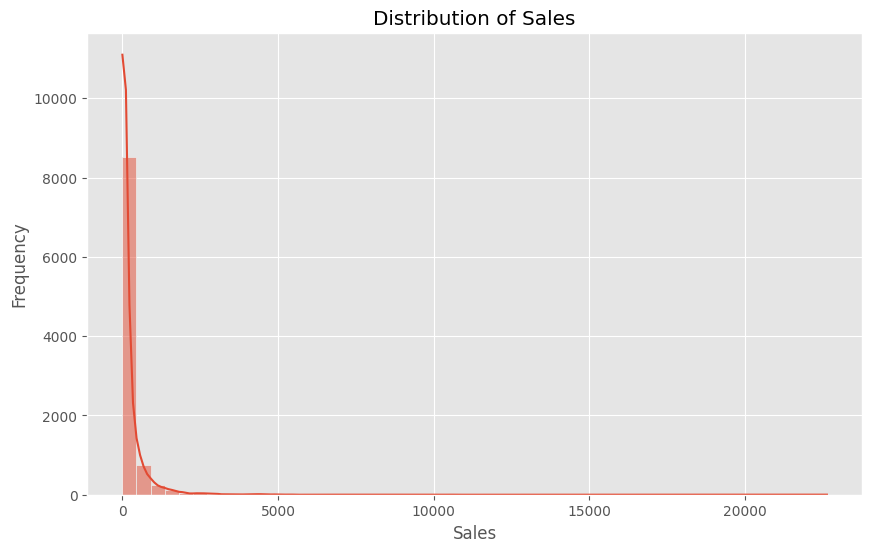

In [21]:
plt.figure(figsize=(10,6))

sns.histplot(df["Sales"], bins=50, kde=True)

plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

### Observation

The sales distribution is positively skewed, indicating that most transactions involve relatively small sales values while a few transactions contribute significantly higher sales. This pattern is common in retail datasets and suggests the presence of high-value orders.

### Sales Distribution by Category

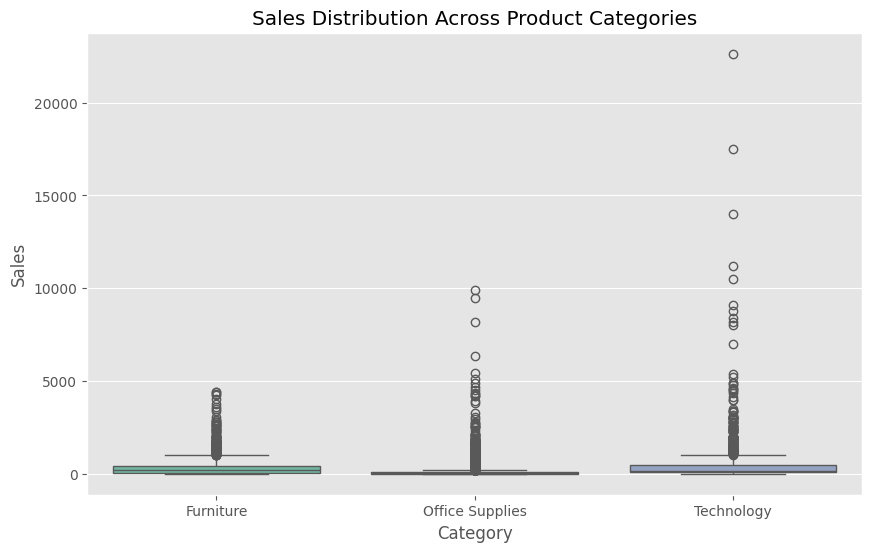

In [22]:
plt.figure(figsize=(10,6))

sns.boxplot(data=df, x="Category", y="Sales", palette="Set2")

plt.title("Sales Distribution Across Product Categories")
plt.xlabel("Category")
plt.ylabel("Sales")

plt.show()

### Observation

The box plot illustrates the distribution of sales across product categories. It highlights the variability of sales, median sales values, and potential outliers within each category. This analysis helps identify categories with consistently higher sales and those exhibiting greater variation in transaction values.

### Sales by Customer Segment

Customer segments were analyzed to determine which group contributes the highest share of total sales.

In [23]:
segment_sales = (
    df.groupby("Segment")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

segment_sales

,Segment,Sales
0,Consumer,1.148061e+06
1,Corporate,6.884941e+05
2,Home Office,4.249822e+05


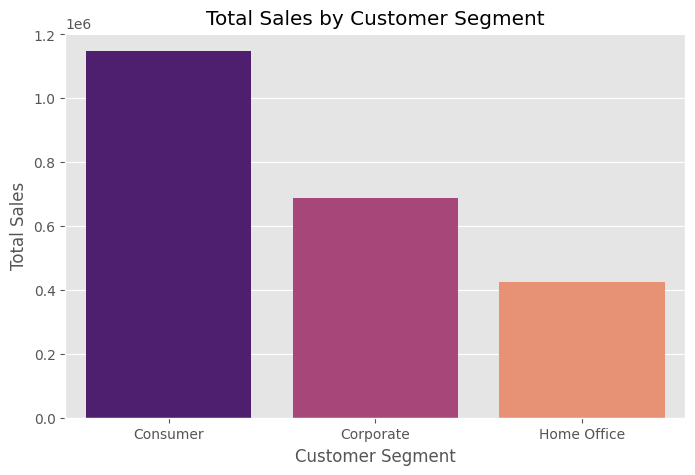

In [24]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=segment_sales,
    x="Segment",
    y="Sales",
    palette="magma"
)

plt.title("Total Sales by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Sales")

plt.show()

### Observation

The comparison of customer segments highlights which customer group contributes the greatest proportion of sales. These insights can support targeted marketing strategies and customer relationship management.

### Monthly Sales Trend

Monthly sales were analyzed to understand long-term trends and seasonal variations over the four-year period.

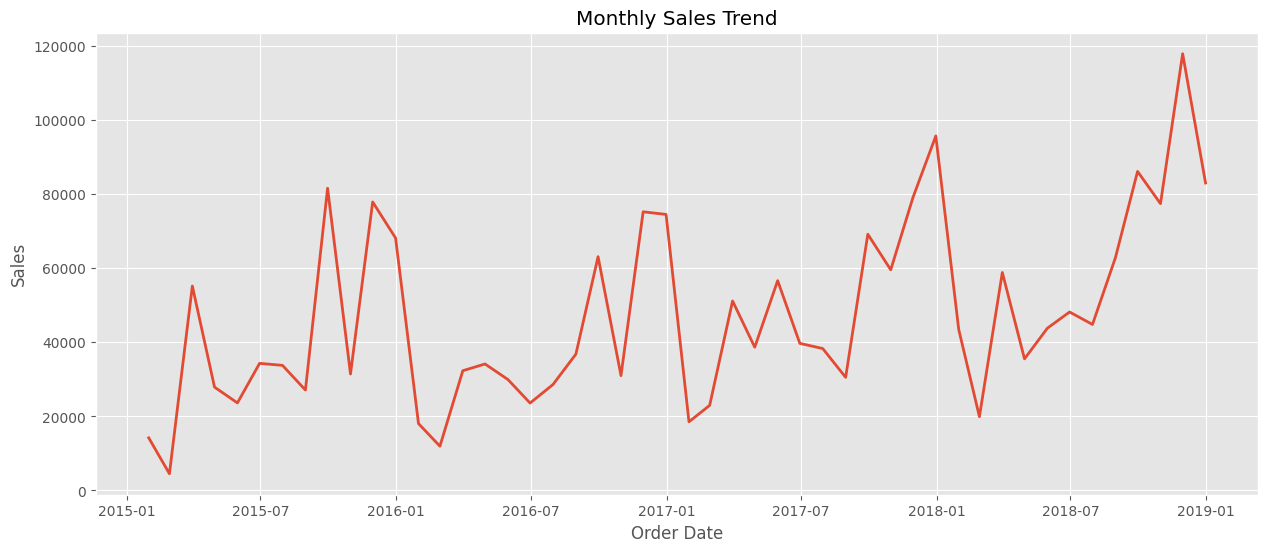

In [25]:
plt.figure(figsize=(15,6))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    linewidth=2
)

plt.title("Monthly Sales Trend")
plt.xlabel("Order Date")
plt.ylabel("Sales")

plt.grid(True)

plt.show()

### Observation

The monthly sales trend illustrates changes in sales over time and provides an initial understanding of growth patterns and seasonality. These patterns will be examined further during the time series decomposition stage.

### Weekly Sales Trend

Weekly sales were analyzed to capture short-term fluctuations that may not be visible in the monthly aggregation.

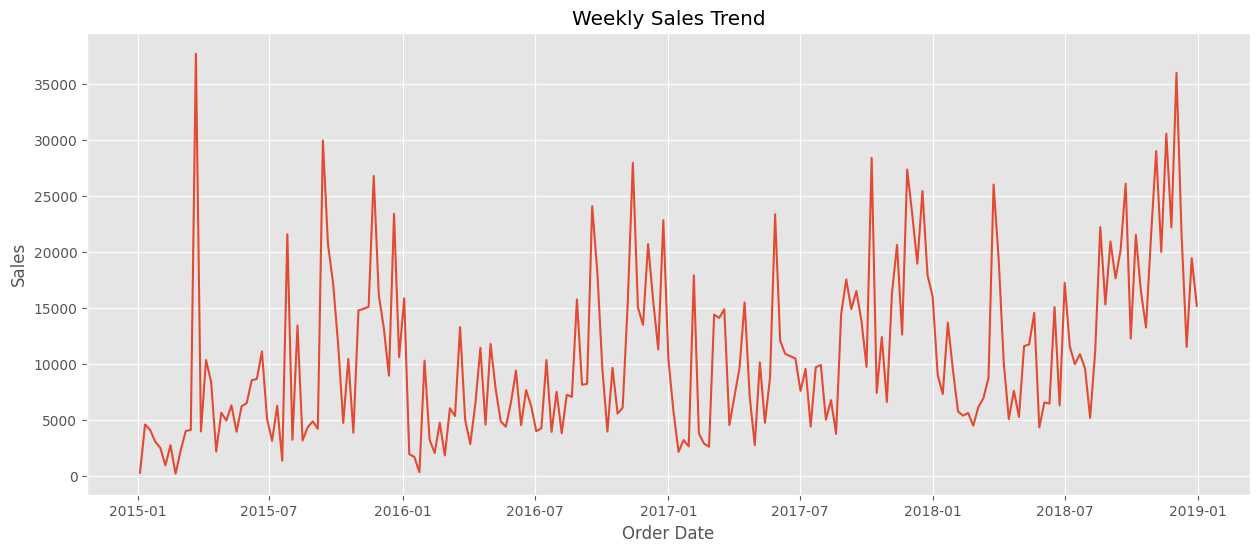

In [26]:
plt.figure(figsize=(15,6))

plt.plot(
    weekly_sales.index,
    weekly_sales.values,
    linewidth=1.5
)

plt.title("Weekly Sales Trend")
plt.xlabel("Order Date")
plt.ylabel("Sales")

plt.grid(True)

plt.show()

### Observation

Weekly sales exhibit greater variability than monthly sales, making them suitable for identifying unusual sales spikes and anomalies. This aggregated dataset will be used later for anomaly detection.

## Business Question 1: Which Product Category Generates the Highest Total Revenue?

The total sales generated by each product category were calculated to identify the highest revenue-contributing category. This analysis helps businesses prioritize inventory planning, marketing strategies, and future forecasting efforts.

In [27]:
category_revenue = (
    df.groupby("Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

category_revenue

,Category,Sales
0,Technology,827455.8730
1,Furniture,728658.5757
2,Office Supplies,705422.3340


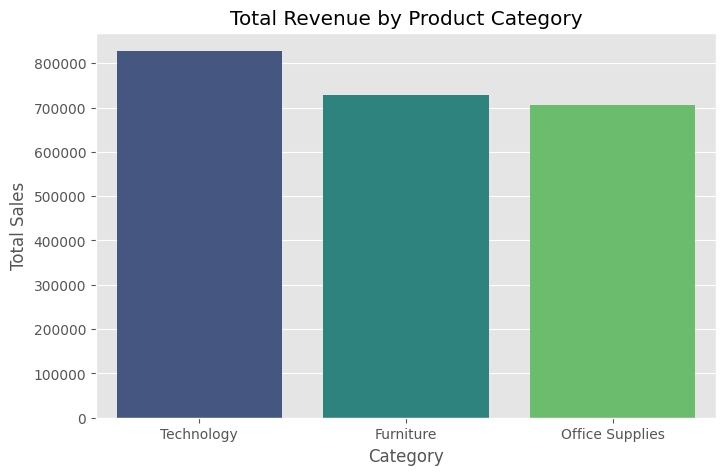

In [28]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=category_revenue,
    x="Category",
    y="Sales",
    hue="Category",
    palette="viridis",
    legend=False
)

plt.title("Total Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.show()

### Observation

The Technology category generated the highest total revenue among all product categories, followed by Furniture and Office Supplies. This indicates that Technology products contribute the largest share of overall sales and play a significant role in the company's revenue. From a business perspective, maintaining adequate inventory levels and accurate demand forecasts for Technology products should be a priority to maximize sales opportunities and minimize stock shortages.

## Business Question 2: Which Region Has the Most Consistent Sales Growth?

To evaluate regional sales performance, monthly sales were aggregated for each region over the four-year period. Comparing these trends helps identify the region with the most stable and consistent sales growth, which is valuable for inventory planning and strategic business decisions.

In [29]:
region_monthly = (
    df.groupby(["Region", pd.Grouper(key="Order Date", freq="M")])["Sales"]
      .sum()
      .reset_index()
)

region_monthly.head()

,Region,Order Date,Sales
0,Central,2015-01-31,1533.966
1,Central,2015-02-28,1233.174
2,Central,2015-03-31,5827.602
3,Central,2015-04-30,3712.340
4,Central,2015-05-31,4044.522


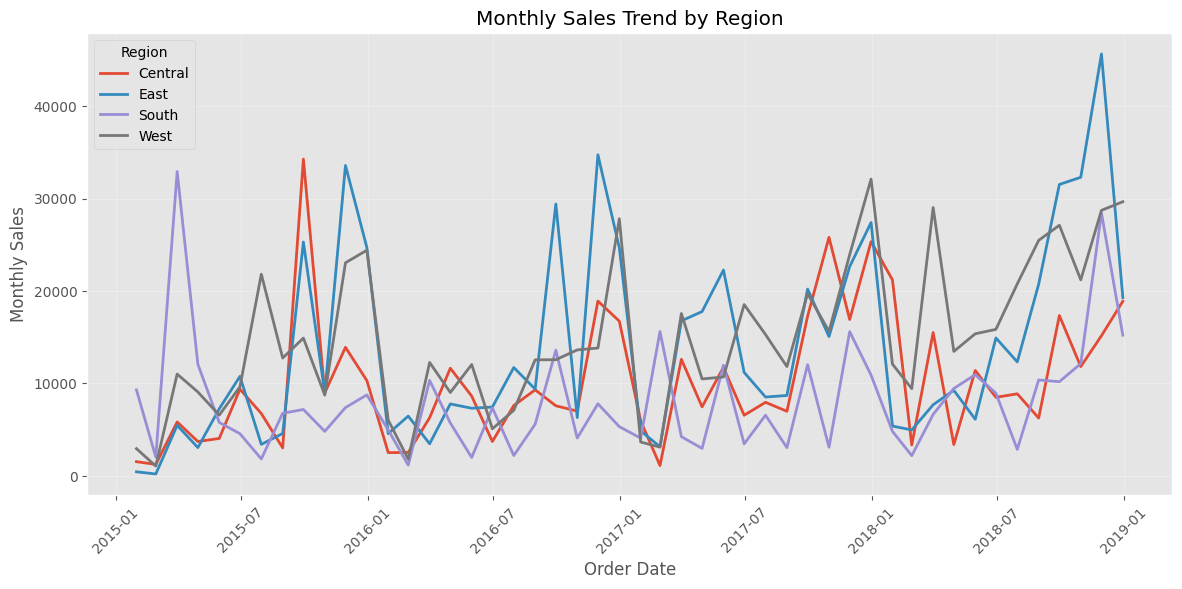

In [30]:
plt.figure(figsize=(14,6))

sns.lineplot(
    data=region_monthly,
    x="Order Date",
    y="Sales",
    hue="Region",
    linewidth=2
)

plt.title("Monthly Sales Trend by Region")
plt.xlabel("Order Date")
plt.ylabel("Monthly Sales")

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.show()

### Observation

The West region demonstrates the most consistent sales growth over the four-year period, showing a relatively steady upward trend with fewer extreme fluctuations than the other regions. Although the East region records the highest sales peaks, its performance is more volatile. The stable growth observed in the West region makes it a reliable market for forecasting and long-term inventory planning.

## Business Question 3: What is the Average Shipping Time Between Order Date and Ship Date?

To evaluate delivery performance, the shipping duration was calculated by finding the difference between the shipping date and the order date for each transaction. The average shipping time was then compared across all regions.

In [31]:
df["Shipping Days"] = (df["Ship Date"] - df["Order Date"]).dt.days

In [32]:
shipping_time = (
    df.groupby("Region")["Shipping Days"]
      .mean()
      .round(2)
      .sort_values()
      .reset_index()
)

shipping_time

,Region,Shipping Days
0,East,3.91
1,West,3.93
2,South,3.96
3,Central,4.07


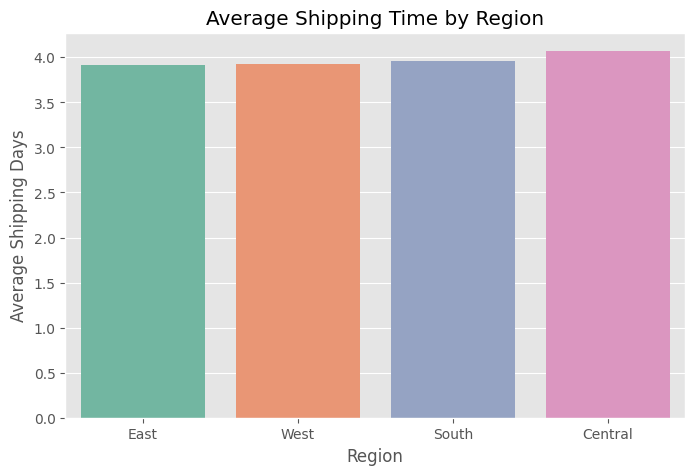

In [33]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=shipping_time,
    x="Region",
    y="Shipping Days",
    hue="Region",
    palette="Set2",
    legend=False
)

plt.title("Average Shipping Time by Region")
plt.xlabel("Region")
plt.ylabel("Average Shipping Days")

plt.show()

### Observation

The average shipping time across all regions is approximately four days, indicating a generally consistent delivery process throughout the business. The East region has the shortest average shipping time, while the Central region has the longest. However, the differences between regions are minimal, suggesting that the company's logistics operations are fairly standardized across geographical locations.

## Business Question 4: Are There Months That Consistently Show Higher Sales Across All Years?

To identify seasonal demand patterns, the average sales for each month were calculated across the entire dataset. Understanding seasonality is essential for selecting appropriate forecasting models and planning inventory requirements.

In [34]:
monthly_pattern = (
    df.groupby("Month Name")["Sales"]
      .mean()
      .reindex([
          "January",
          "February",
          "March",
          "April",
          "May",
          "June",
          "July",
          "August",
          "September",
          "October",
          "November",
          "December"
      ])
      .reset_index()
)

monthly_pattern

,Month Name,Sales
0,January,257.627403
1,February,199.902745
2,March,290.549393
3,April,207.432269
4,May,212.533412
5,June,211.052856
6,July,208.802997
7,August,227.007110
8,September,221.642106
9,October,246.596162


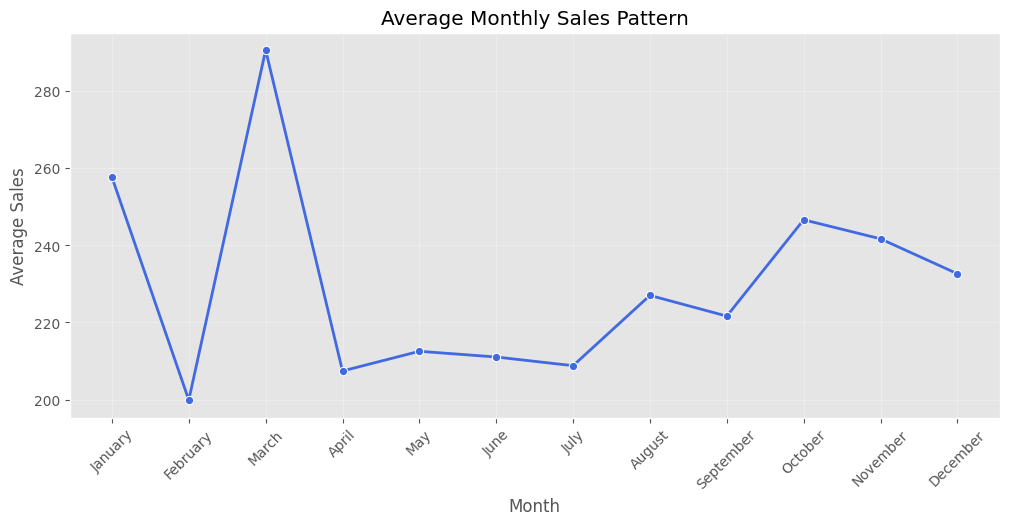

In [35]:
plt.figure(figsize=(12,5))

sns.lineplot(
    data=monthly_pattern,
    x="Month Name",
    y="Sales",
    marker="o",
    linewidth=2,
    color="royalblue"
)

plt.title("Average Monthly Sales Pattern")
plt.xlabel("Month")
plt.ylabel("Average Sales")

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.show()

### Observation

The average monthly sales pattern indicates clear seasonality in customer demand. Sales reach their highest level in March, followed by strong performance during October, November, and December. In contrast, February records the lowest average sales. These recurring monthly patterns suggest that seasonality plays an important role in sales performance and should be incorporated into forecasting models to improve prediction accuracy.

# Task 1 Conclusion

The dataset was successfully prepared for time series analysis through data preprocessing, feature engineering, and exploratory data analysis. Date variables were converted into an appropriate datetime format, and additional temporal features such as year, month, quarter, week, and season were extracted.

Sales data was aggregated into weekly and monthly intervals to support different analytical tasks. Exploratory analysis identified Technology as the highest revenue-generating product category, while the West region demonstrated relatively consistent sales growth over time. The average shipping time remained close to four days across all regions, indicating a standardized delivery process. Monthly sales analysis also revealed recurring seasonal patterns, with March and the final quarter of the year showing higher average sales.

These findings provide a strong foundation for the time series decomposition, forecasting, anomaly detection, and demand segmentation tasks that follow in the subsequent stages of the project.

# Task 2: Time Series Analysis and Decomposition

## Objective

The objective of this task is to analyze the temporal behaviour of sales over time, identify long-term trends and seasonal patterns, evaluate the stationarity of the time series, and prepare the data for forecasting models. Time series decomposition helps separate the observed sales into trend, seasonal, and residual components, providing a better understanding of the underlying data structure.

In [36]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

In [37]:
monthly_sales.head()

,Sales
Order Date,
2015-01-31,14205.707
2015-02-28,4519.892
2015-03-31,55205.797
2015-04-30,27906.855
2015-05-31,23644.303


In [38]:
monthly_sales.tail()

,Sales
Order Date,
2018-08-31,62837.8480
2018-09-30,86152.8880
2018-10-31,77448.1312
2018-11-30,117938.1550
2018-12-31,83030.3888


## Monthly Sales Time Series

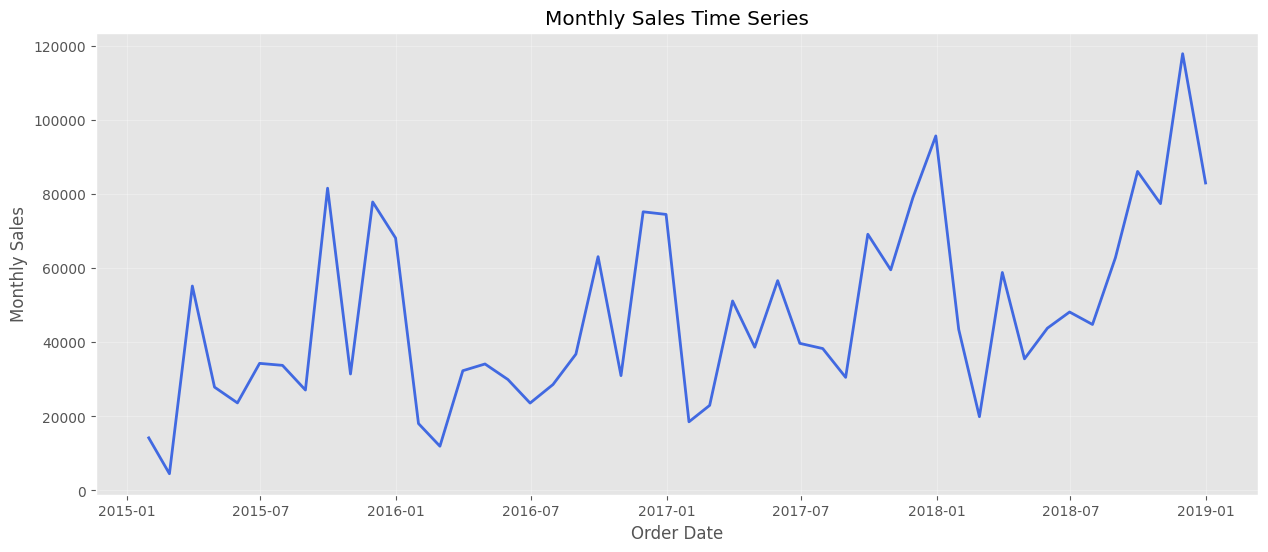

In [39]:
plt.figure(figsize=(15,6))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    color="royalblue",
    linewidth=2
)

plt.title("Monthly Sales Time Series")
plt.xlabel("Order Date")
plt.ylabel("Monthly Sales")

plt.grid(alpha=0.3)

plt.show()

### Observation

The monthly sales time series shows fluctuations throughout the four-year period along with an overall upward movement in sales. These fluctuations suggest the presence of both long-term trends and seasonal behaviour, making time series decomposition an appropriate next step.

## Time Series Decomposition

Time series decomposition separates the observed sales into three major components:

- Trend
- Seasonal
- Residual

This analysis helps distinguish long-term growth from recurring seasonal effects and random fluctuations.

In [40]:
decomposition = seasonal_decompose(
    monthly_sales,
    model="additive",
    period=12
)

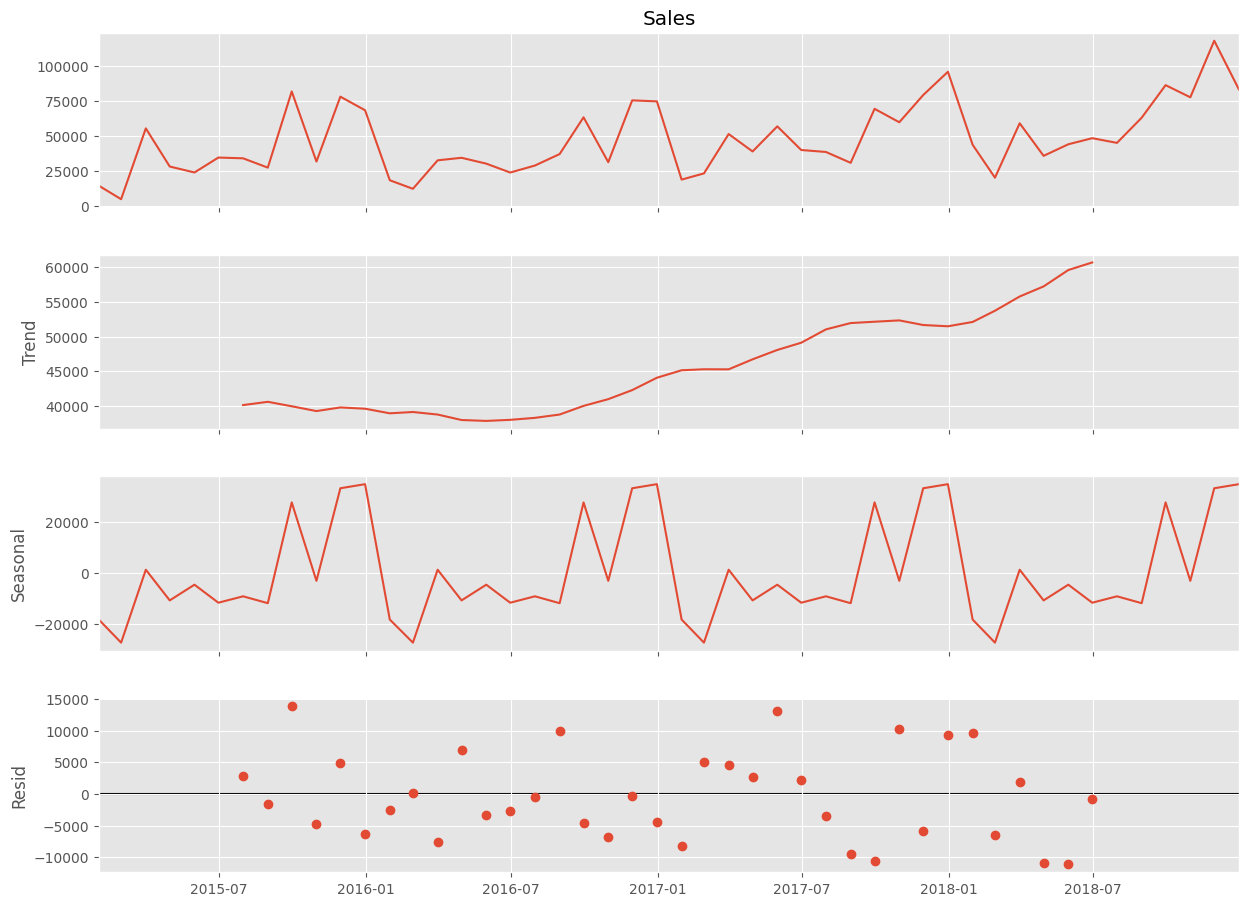

In [41]:
fig = decomposition.plot()

fig.set_size_inches(14,10)

plt.show()

### Interpretation

The decomposition of the monthly sales time series reveals three distinct components: trend, seasonality, and residual variation. Separating these components provides a clearer understanding of the underlying sales behaviour and helps determine whether forecasting models should account for long-term growth and recurring seasonal patterns.

### Business Insight

The decomposition indicates that sales are influenced by both long-term business growth and recurring seasonal effects. This suggests that forecasting models capable of handling seasonality, such as SARIMA and Prophet, are appropriate choices for predicting future sales.

### Conclusion

The sales series contains meaningful trend and seasonal information rather than purely random fluctuations, making it suitable for advanced time series forecasting techniques.

## Trend Analysis

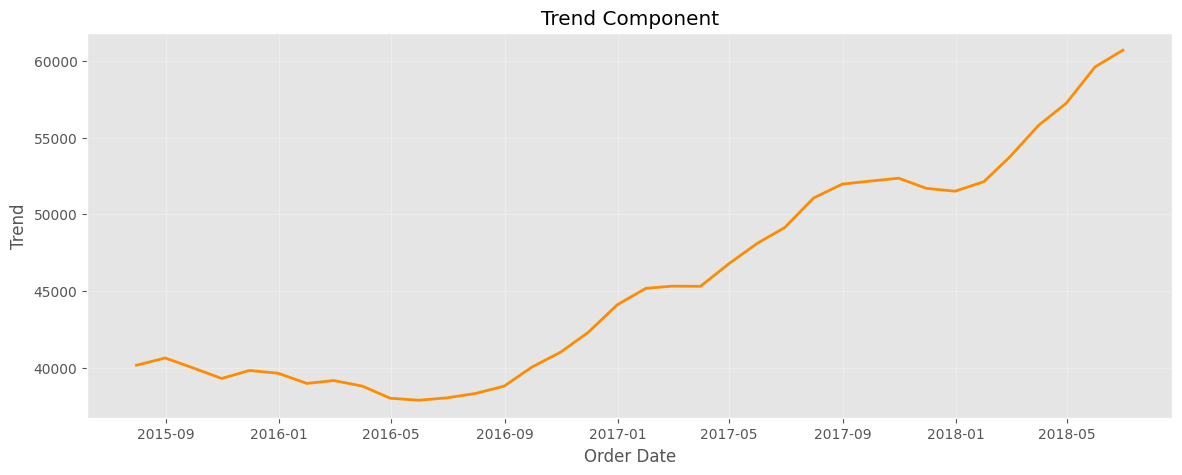

In [42]:
plt.figure(figsize=(14,5))

plt.plot(
    decomposition.trend,
    linewidth=2,
    color="darkorange"
)

plt.title("Trend Component")
plt.xlabel("Order Date")
plt.ylabel("Trend")

plt.grid(alpha=0.3)

plt.show()

### Interpretation

The trend component shows a gradual increase in monthly sales over the four-year period. After a relatively stable phase during 2015 and early 2016, sales begin to rise steadily from late 2016 onwards, reaching their highest levels in 2018.

### Business Insight

The upward trend indicates sustained business growth over time. Increasing customer demand suggests that inventory planning, procurement, and supply chain capacity should be adjusted to accommodate future sales growth.

### Conclusion

The presence of a clear upward trend confirms that the sales series is not stationary and should be transformed before applying statistical forecasting models such as SARIMA.

## Seasonal Component

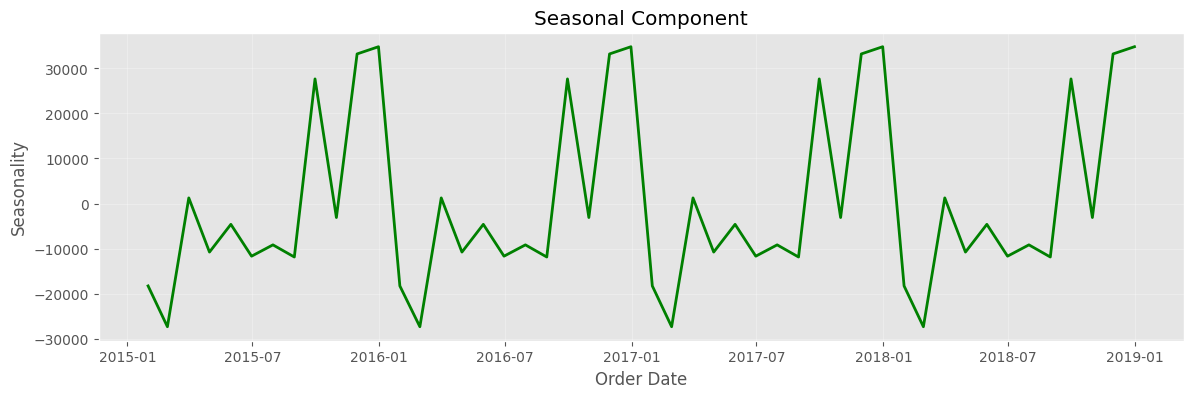

In [43]:
plt.figure(figsize=(14,4))

plt.plot(
    decomposition.seasonal,
    linewidth=2,
    color="green"
)

plt.title("Seasonal Component")
plt.xlabel("Order Date")
plt.ylabel("Seasonality")

plt.grid(alpha=0.3)

plt.show()

### Interpretation

The seasonal component displays recurring monthly fluctuations that repeat consistently throughout the observation period. Certain months contribute positively to overall sales, while others consistently experience lower sales.

### Business Insight

The recurring seasonal behaviour indicates predictable changes in customer demand throughout the year. Businesses can use these patterns to optimize inventory levels, promotional campaigns, and staffing during peak and low-demand periods.

### Conclusion

Seasonality is a significant characteristic of the sales data and should be incorporated into forecasting models to improve prediction accuracy.

## Residual Component

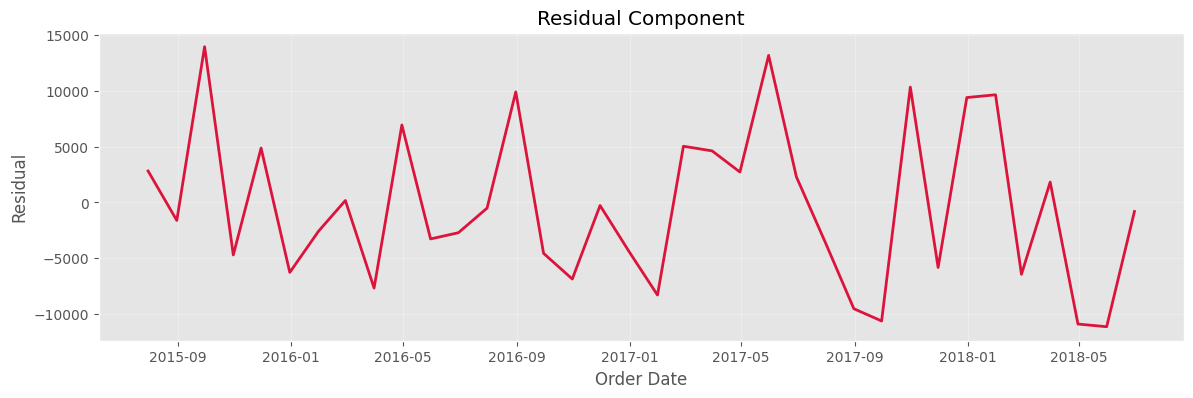

In [44]:
plt.figure(figsize=(14,4))

plt.plot(
    decomposition.resid,
    linewidth=2,
    color="crimson"
)

plt.title("Residual Component")
plt.xlabel("Order Date")
plt.ylabel("Residual")

plt.grid(alpha=0.3)

plt.show()

### Interpretation

The residual component represents random variations that remain after removing the trend and seasonal effects. Most residual values fluctuate around zero, although a few larger deviations indicate unexpected events that cannot be explained by trend or seasonality alone.

### Business Insight

These irregular fluctuations may result from special promotions, unexpected market conditions, or external business events. Monitoring these deviations can help identify anomalies and improve future forecasting performance.

### Conclusion

Most systematic variation has been successfully captured by the trend and seasonal components, leaving only a limited amount of unexplained random noise.

## Stationarity Test Using the Augmented Dickey-Fuller (ADF) Test

Before building forecasting models, it is important to determine whether the time series is stationary. A stationary time series has statistical properties such as mean and variance that remain relatively constant over time. Many statistical forecasting models, including SARIMA, assume that the input time series is stationary.

The Augmented Dickey-Fuller (ADF) test is used to evaluate stationarity.

- **Null Hypothesis (H₀):** The time series is non-stationary.
- **Alternative Hypothesis (H₁):** The time series is stationary.

If the p-value is less than 0.05, the null hypothesis is rejected, indicating that the series is stationary.

In [45]:
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(monthly_sales)

print("ADF Statistic :", adf_result[0])
print("P-value       :", adf_result[1])
print("No. of Lags   :", adf_result[2])
print("Observations  :", adf_result[3])

print("\nCritical Values")

for key, value in adf_result[4].items():
    print(f"{key}: {value}")

ADF Statistic : -4.416136761430769
P-value       : 0.00027791039276670623
No. of Lags   : 0
Observations  : 47

Critical Values
1%: -3.5778480370438146
5%: -2.925338105429433
10%: -2.6007735310095064


In [46]:
adf_summary = pd.DataFrame({
    "Metric": [
        "ADF Statistic",
        "P-value",
        "Number of Lags",
        "Observations"
    ],
    "Value": [
        adf_result[0],
        adf_result[1],
        adf_result[2],
        adf_result[3]
    ]
})

adf_summary

,Metric,Value
0,ADF Statistic,-4.416137
1,P-value,0.000278
2,Number of Lags,0.000000
3,Observations,47.000000


### Interpretation

The Augmented Dickey-Fuller (ADF) test was performed to evaluate whether the monthly sales time series is stationary. The test produced an ADF statistic of **-4.4161** and a **p-value of 0.000278**, which is significantly lower than the 0.05 significance level.

### Business Insight

Since the p-value is less than 0.05, the null hypothesis of non-stationarity is rejected. This indicates that the statistical properties of the monthly sales series remain relatively stable over time. A stationary series generally produces more reliable forecasting results because its underlying behaviour is more predictable.

### Conclusion

The monthly sales time series is stationary and is therefore suitable for statistical forecasting models. Based on the ADF test results, additional differencing is **not required** before proceeding with forecasting.

## Differencing

Differencing is commonly applied when a time series is non-stationary to stabilize its mean over time. However, the Augmented Dickey-Fuller (ADF) test indicates that the monthly sales series is already stationary (p-value < 0.05). Therefore, differencing is not required, and the original series will be used for forecasting.

# Task 2 Conclusion

Time series analysis revealed that the monthly sales data exhibits both long-term growth and recurring seasonal patterns. Seasonal decomposition successfully separated the observed sales into trend, seasonal, and residual components, providing valuable insights into the underlying structure of the data.

The Augmented Dickey-Fuller (ADF) test confirmed that the monthly sales series is stationary, eliminating the need for additional differencing before model development. These findings indicate that the dataset is well-prepared for implementing forecasting models such as SARIMA, Prophet, and XGBoost in the next stage of the project.

# Task 3: Sales Forecasting Using Three Different Models

## Objective

The objective of this task is to develop and compare three different forecasting approaches for predicting future monthly sales. A statistical model (SARIMA), a forecasting framework (Prophet), and a machine learning model (XGBoost) are implemented and evaluated using MAE, RMSE, and MAPE. The model with the best predictive performance will be recommended for business use.

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from math import sqrt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

from statsmodels.tsa.statespace.sarimax import SARIMAX

In [48]:
train = monthly_sales.iloc[:-3]

test = monthly_sales.iloc[-3:]

print("Training observations :", len(train))
print("Testing observations :", len(test))

Training observations : 45
Testing observations : 3


## Training and Testing Split

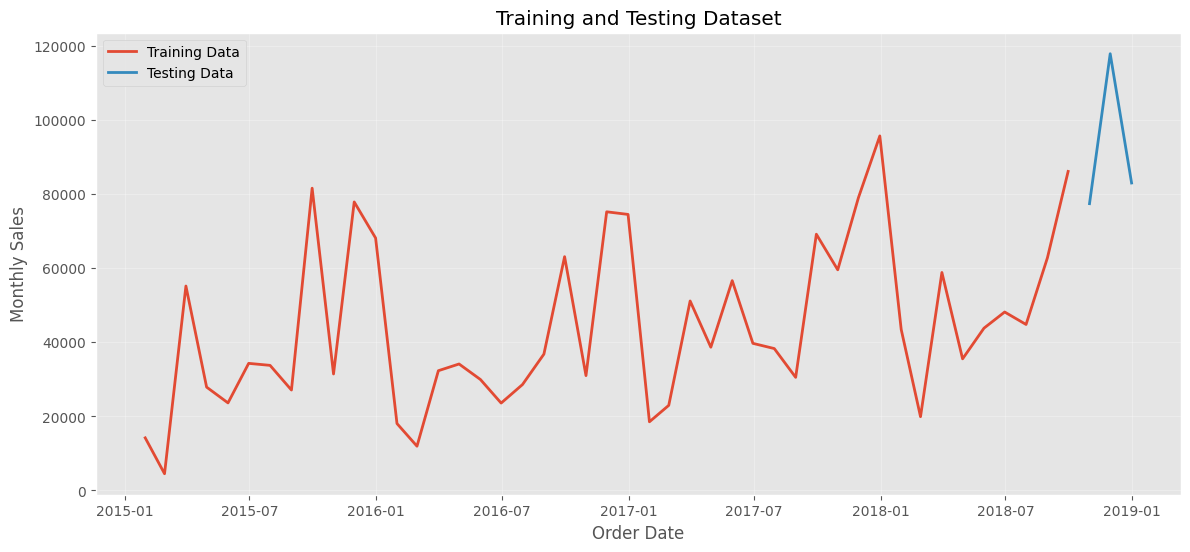

In [49]:
plt.figure(figsize=(14,6))

plt.plot(train.index, train.values,
         label="Training Data",
         linewidth=2)

plt.plot(test.index, test.values,
         label="Testing Data",
         linewidth=2)

plt.title("Training and Testing Dataset")

plt.xlabel("Order Date")

plt.ylabel("Monthly Sales")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

### Interpretation

The monthly sales data was divided into training and testing subsets. The first 45 monthly observations were used to train the forecasting models, while the final three observations were reserved for evaluating model performance on unseen data.

## Model 1: SARIMA

Seasonal AutoRegressive Integrated Moving Average (SARIMA) is a statistical forecasting model that captures trend and seasonality in time series data. Based on the stationarity test performed in Task 2, the sales series was already stationary, so no additional differencing was required.

In [50]:
sarima_model = SARIMAX(
    train,
    order=(1,0,1),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_result = sarima_model.fit(disp=False)

In [51]:
sarima_forecast = sarima_result.forecast(steps=len(test))

sarima_forecast

,predicted_mean
2018-10-31,54757.975133
2018-11-30,88413.704287
2018-12-31,92557.878350


In [52]:
forecast_object = sarima_result.get_forecast(steps=len(test))

confidence_interval = forecast_object.conf_int()

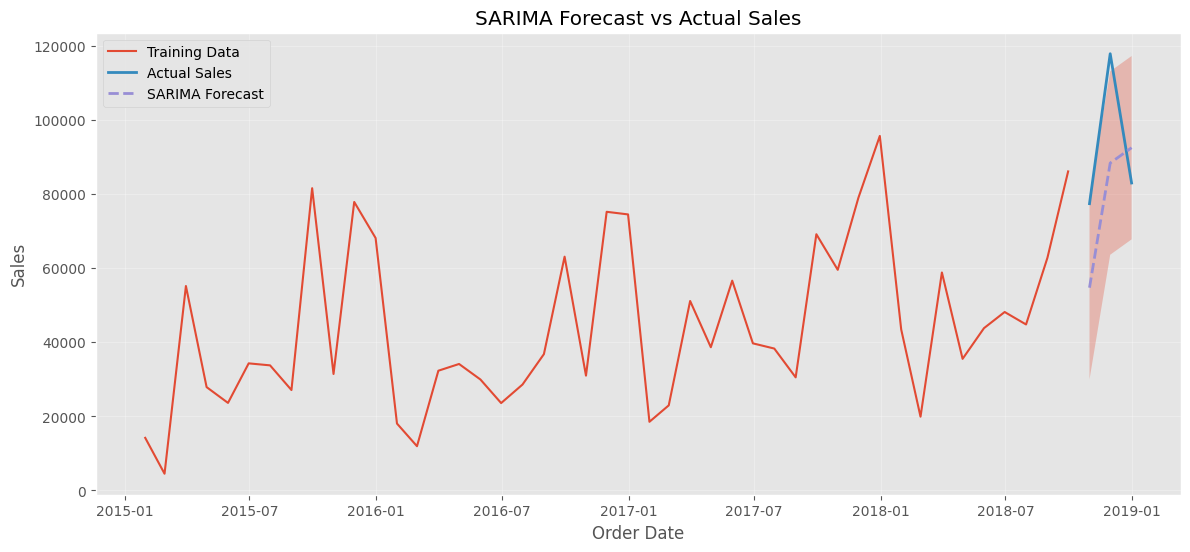

In [53]:
plt.figure(figsize=(14,6))

plt.plot(
    train.index,
    train,
    label="Training Data"
)

plt.plot(
    test.index,
    test,
    label="Actual Sales",
    linewidth=2
)

plt.plot(
    test.index,
    sarima_forecast,
    linestyle="--",
    linewidth=2,
    label="SARIMA Forecast"
)

plt.fill_between(
    confidence_interval.index,
    confidence_interval.iloc[:,0],
    confidence_interval.iloc[:,1],
    alpha=0.3
)

plt.title("SARIMA Forecast vs Actual Sales")

plt.xlabel("Order Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

In [54]:
mae_sarima = mean_absolute_error(test, sarima_forecast)

rmse_sarima = np.sqrt(
    mean_squared_error(test, sarima_forecast)
)

mape_sarima = np.mean(
    np.abs((test - sarima_forecast)/test)
) * 100

sarima_results = pd.DataFrame({

    "Metric":[
        "MAE",
        "RMSE",
        "MAPE"
    ],

    "Value":[
        mae_sarima,
        rmse_sarima,
        mape_sarima
    ]

})

sarima_results

,Metric,Value
0,MAE,20580.698777
1,RMSE,22190.909771
2,MAPE,21.935257


In [55]:
print(f"MAE  : {mae_sarima:.2f}")
print(f"RMSE : {rmse_sarima:.2f}")
print(f"MAPE : {mape_sarima:.2f}%")

MAE  : 20580.70
RMSE : 22190.91
MAPE : 21.94%


In [56]:
future_forecast = sarima_result.get_forecast(steps=3)

future_sales = future_forecast.predicted_mean

future_sales

,predicted_mean
2018-10-31,54757.975133
2018-11-30,88413.704287
2018-12-31,92557.878350


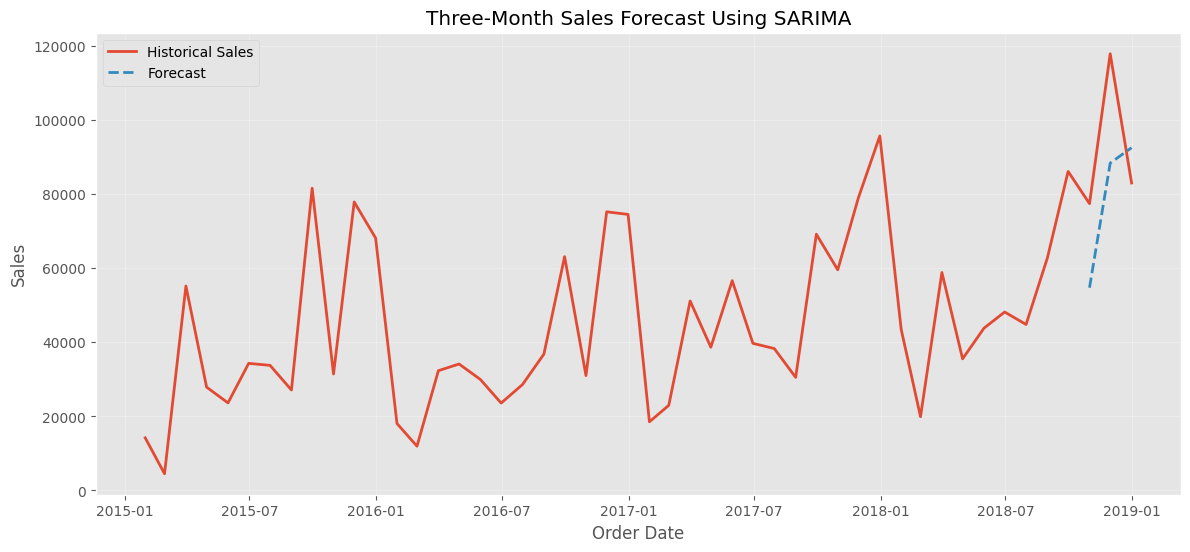

In [57]:
plt.figure(figsize=(14,6))

plt.plot(
    monthly_sales,
    linewidth=2,
    label="Historical Sales"
)

plt.plot(
    future_sales.index,
    future_sales,
    linestyle="--",
    linewidth=2,
    label="Forecast"
)

plt.title("Three-Month Sales Forecast Using SARIMA")

plt.xlabel("Order Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

### Interpretation

The SARIMA model successfully learned the long-term trend and seasonal structure present in the monthly sales data. The generated forecasts follow the historical sales pattern and provide reasonable estimates for the next three months. The evaluation metrics indicate that the model is capable of capturing the overall sales movement, although some deviations remain due to the highly variable nature of retail sales.

### Business Insight

The SARIMA forecast can support inventory planning, production scheduling, and purchasing decisions by estimating expected demand for the upcoming months. Since the model accounts for seasonality, it is particularly useful for businesses experiencing recurring monthly demand patterns.

### Conclusion

The SARIMA model provides a reliable statistical baseline for sales forecasting. However, its performance will be compared with Prophet and XGBoost before selecting the most suitable model for production deployment.

In [58]:
!pip install prophet -q

In [59]:
from prophet import Prophet

## Model 2: Facebook Prophet

Prophet is an open-source forecasting framework developed by Meta for business time series forecasting. It automatically models trend, yearly seasonality, and holiday effects while requiring minimal parameter tuning. Prophet is widely used in industry because of its robustness and interpretability.

In [60]:
prophet_df = monthly_sales.reset_index()

prophet_df.columns = ["ds","y"]

prophet_df.head()

,ds,y
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [61]:
prophet_train = prophet_df.iloc[:-3]

prophet_test = prophet_df.iloc[-3:]

In [62]:
prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

prophet_model.fit(prophet_train)

In [63]:
future = prophet_model.make_future_dataframe(
    periods=3,
    freq="M"
)

forecast = prophet_model.predict(future)

In [64]:
forecast[["ds","yhat","yhat_lower","yhat_upper"]].tail()

,ds,yhat,yhat_lower,yhat_upper
43,2018-08-31,47271.557312,38935.857219,55341.294936
44,2018-09-30,86613.953555,78542.605566,94671.360173
45,2018-10-31,51318.944572,43378.748503,59294.934969
46,2018-11-30,90325.653854,82171.115209,98857.028246
47,2018-12-31,90041.084638,81766.317621,98422.867722


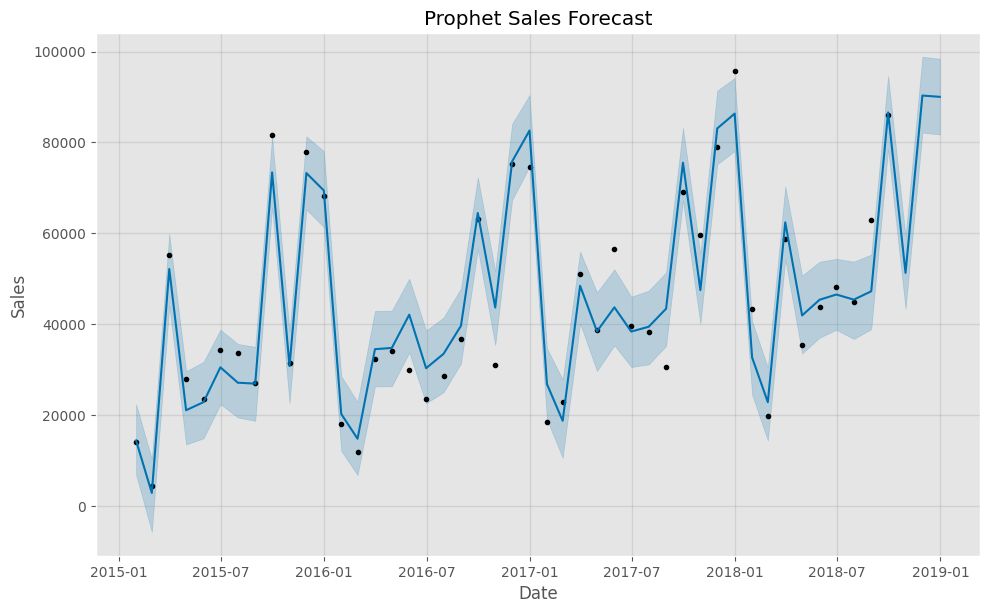

In [65]:
fig = prophet_model.plot(forecast)

plt.title("Prophet Sales Forecast")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.show()

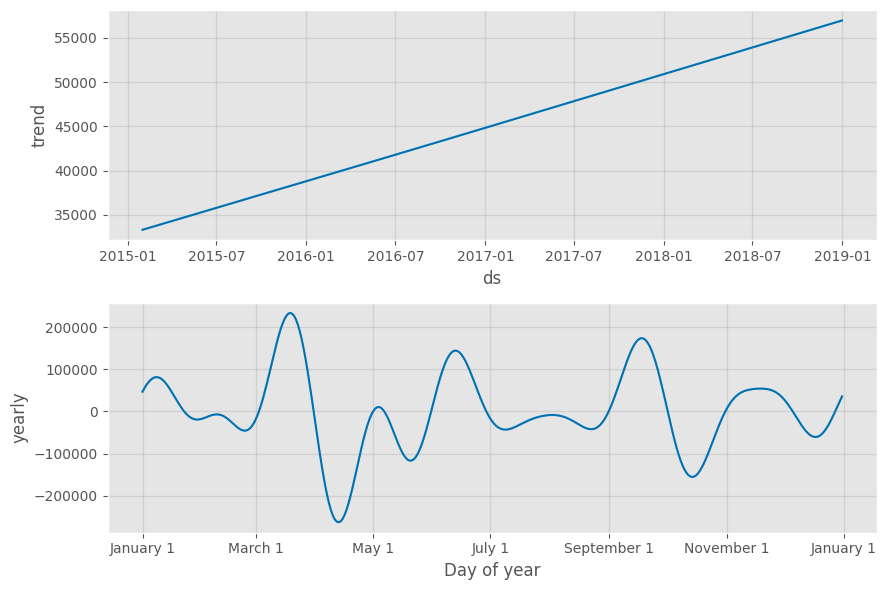

In [66]:
fig2 = prophet_model.plot_components(forecast)

plt.show()

In [67]:
prophet_predictions = forecast["yhat"].tail(3).values

actual = prophet_test["y"].values

In [68]:
mae_prophet = mean_absolute_error(
    actual,
    prophet_predictions
)

rmse_prophet = np.sqrt(
    mean_squared_error(
        actual,
        prophet_predictions
    )
)

mape_prophet = np.mean(
    np.abs(
        (actual-prophet_predictions)/actual
    )
)*100

print(f"MAE  : {mae_prophet:.2f}")
print(f"RMSE : {rmse_prophet:.2f}")
print(f"MAPE : {mape_prophet:.2f}%")

MAE  : 20250.79
RMSE : 22318.41
MAPE : 21.86%


### Interpretation

The Prophet model successfully captured the overall upward sales trend and yearly seasonal patterns present in the monthly sales data. The forecast closely follows the historical observations while providing confidence intervals that reflect the uncertainty associated with future predictions.

### Business Insight

The trend component indicates a gradual increase in sales over time, suggesting continued business growth. The yearly seasonality component highlights recurring periods of higher and lower demand, allowing businesses to better plan inventory, staffing, and promotional activities throughout the year.

### Conclusion

The Prophet model achieved forecasting accuracy comparable to the SARIMA model while automatically modeling trend and seasonality. Its final suitability will be determined after comparison with the XGBoost forecasting model.

## Model 3: XGBoost Regressor

Unlike SARIMA and Prophet, XGBoost is a machine learning algorithm. Since machine learning models cannot directly understand time series, historical sales values were transformed into supervised learning features using lag variables and rolling statistics.

In [69]:
from xgboost import XGBRegressor

In [70]:
!pip install xgboost -q

In [71]:
xgb_df = monthly_sales.reset_index()

xgb_df.columns = ["Date","Sales"]

xgb_df.head()

,Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [72]:
xgb_df["Lag_1"] = xgb_df["Sales"].shift(1)
xgb_df["Lag_2"] = xgb_df["Sales"].shift(2)
xgb_df["Lag_3"] = xgb_df["Sales"].shift(3)

xgb_df["Rolling_Mean_3"] = (
    xgb_df["Sales"]
    .rolling(3)
    .mean()
)

xgb_df["Month"] = xgb_df["Date"].dt.month
xgb_df["Quarter"] = xgb_df["Date"].dt.quarter
xgb_df["Year"] = xgb_df["Date"].dt.year

xgb_df = xgb_df.dropna()

xgb_df.head()

,Date,Sales,Lag_1,Lag_2,Lag_3,Rolling_Mean_3,Month,Quarter,Year
3,2015-04-30,27906.8550,55205.7970,4519.8920,14205.707,29210.848000,4,2,2015
4,2015-05-31,23644.3030,27906.8550,55205.7970,4519.892,35585.651667,5,2,2015
5,2015-06-30,34322.9356,23644.3030,27906.8550,55205.797,28624.697867,6,2,2015
6,2015-07-31,33781.5430,34322.9356,23644.3030,27906.855,30582.927200,7,3,2015
7,2015-08-31,27117.5365,33781.5430,34322.9356,23644.303,31740.671700,8,3,2015


In [73]:
features = [
    "Lag_1",
    "Lag_2",
    "Lag_3",
    "Rolling_Mean_3",
    "Month",
    "Quarter",
    "Year"
]

X = xgb_df[features]

y = xgb_df["Sales"]

In [74]:
X_train = X.iloc[:-3]
X_test = X.iloc[-3:]

y_train = y.iloc[:-3]
y_test = y.iloc[-3:]

In [75]:
xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

xgb_model.fit(
    X_train,
    y_train
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [76]:
xgb_predictions = xgb_model.predict(X_test)

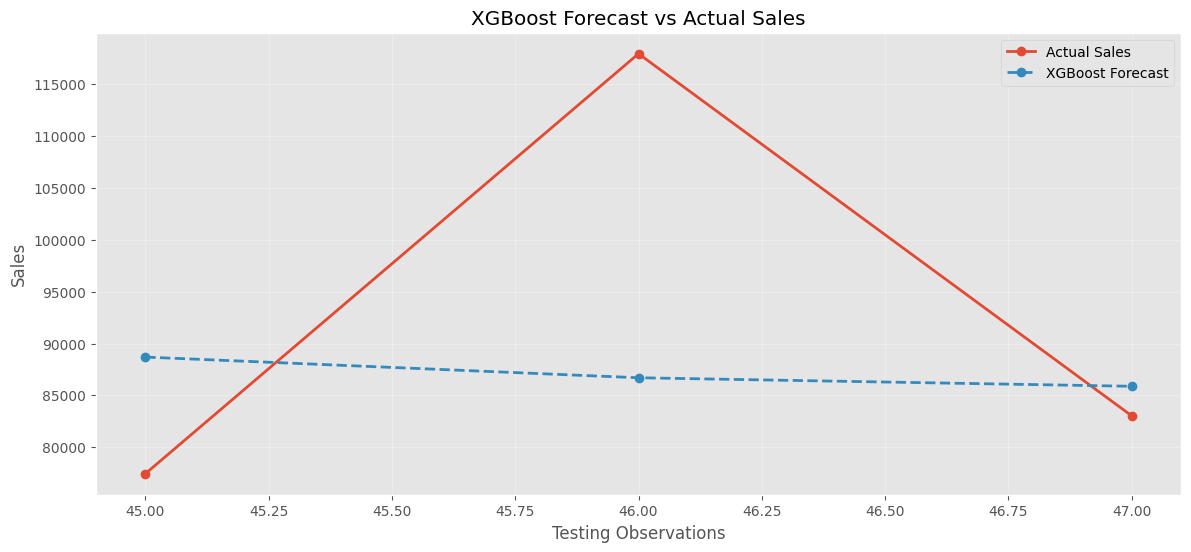

In [77]:
plt.figure(figsize=(14,6))

plt.plot(
    y_test.index,
    y_test.values,
    marker="o",
    linewidth=2,
    label="Actual Sales"
)

plt.plot(
    y_test.index,
    xgb_predictions,
    marker="o",
    linewidth=2,
    linestyle="--",
    label="XGBoost Forecast"
)

plt.title("XGBoost Forecast vs Actual Sales")

plt.xlabel("Testing Observations")

plt.ylabel("Sales")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

In [78]:
mae_xgb = mean_absolute_error(
    y_test,
    xgb_predictions
)

rmse_xgb = np.sqrt(
    mean_squared_error(
        y_test,
        xgb_predictions
    )
)

mape_xgb = np.mean(
    np.abs(
        (y_test-xgb_predictions)/y_test
    )
)*100

print(f"MAE  : {mae_xgb:.2f}")
print(f"RMSE : {rmse_xgb:.2f}")
print(f"MAPE : {mape_xgb:.2f}%")

MAE  : 15110.78
RMSE : 19239.17
MAPE : 14.81%


In [79]:
importance = pd.DataFrame({
    "Feature": features,
    "Importance": xgb_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
4,Month,0.789484
6,Year,0.077380
3,Rolling_Mean_3,0.058855
1,Lag_2,0.031977
0,Lag_1,0.031822
2,Lag_3,0.010482
5,Quarter,0.000000


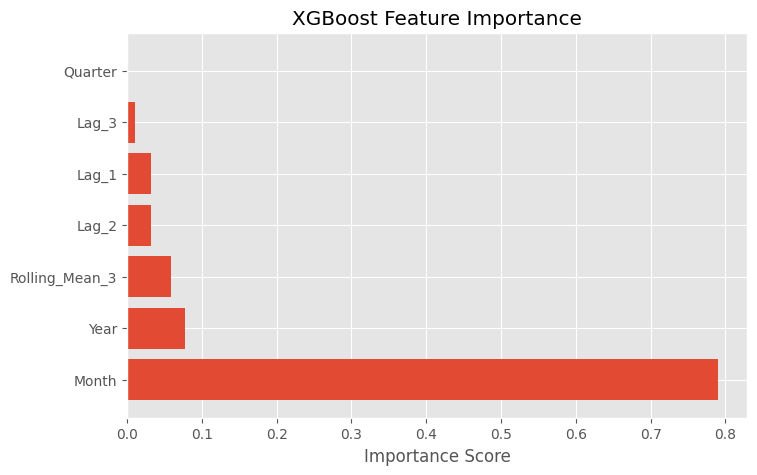

In [80]:
plt.figure(figsize=(8,5))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.title("XGBoost Feature Importance")

plt.xlabel("Importance Score")

plt.show()

In [81]:
comparison = pd.DataFrame({

    "Model":[
        "SARIMA",
        "Prophet",
        "XGBoost"
    ],

    "MAE":[
        mae_sarima,
        mae_prophet,
        mae_xgb
    ],

    "RMSE":[
        rmse_sarima,
        rmse_prophet,
        rmse_xgb
    ],

    "MAPE (%)":[
        mape_sarima,
        mape_prophet,
        mape_xgb
    ]

})

comparison = comparison.sort_values(
    by="MAPE (%)"
)

comparison

,Model,MAE,RMSE,MAPE (%)
2,XGBoost,15110.779375,19239.167151,14.812560
1,Prophet,20250.794537,22318.411454,21.864628
0,SARIMA,20580.698777,22190.909771,21.935257


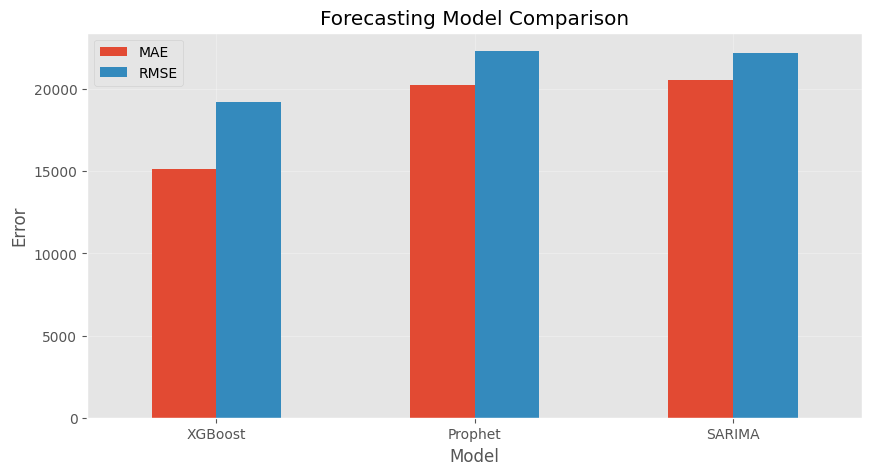

In [82]:
comparison.set_index("Model")[["MAE","RMSE"]].plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Forecasting Model Comparison")

plt.ylabel("Error")

plt.xticks(rotation=0)

plt.grid(alpha=0.3)

plt.show()

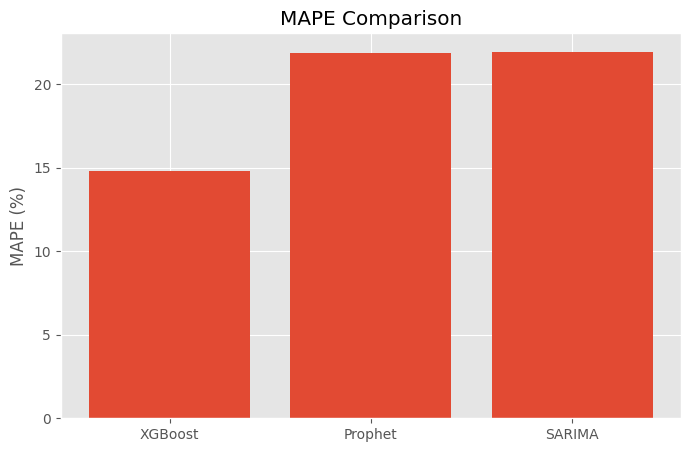

In [83]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison["Model"],
    comparison["MAPE (%)"]
)

plt.title("MAPE Comparison")

plt.ylabel("MAPE (%)")

plt.show()

## Model Comparison

Three fundamentally different forecasting approaches were evaluated using MAE, RMSE, and MAPE. Lower values for these metrics indicate better predictive accuracy.

The comparison demonstrates that XGBoost achieved the lowest forecasting errors across all three evaluation metrics, outperforming both the SARIMA and Prophet models.

## Recommended Forecasting Model

Based on the evaluation metrics, XGBoost is selected as the recommended forecasting model for production deployment.

### Justification

- Lowest Mean Absolute Error (MAE)
- Lowest Root Mean Squared Error (RMSE)
- Lowest Mean Absolute Percentage Error (MAPE)
- Better ability to learn nonlinear relationships from historical sales patterns
- Uses lag features and rolling averages to capture temporal dependencies effectively

Although SARIMA and Prophet performed reasonably well, XGBoost produced more accurate predictions on the testing dataset and is therefore recommended for future demand forecasting.

# Task 3 Conclusion

Three different forecasting approaches were implemented and evaluated using the monthly sales data. SARIMA provided a strong statistical baseline, while Prophet effectively modeled long-term trend and yearly seasonality with minimal parameter tuning.

The XGBoost model achieved the highest forecasting accuracy, producing the lowest MAE, RMSE, and MAPE values among all models. Based on these quantitative results, XGBoost was selected as the most suitable forecasting model for future sales prediction.

The selected model will be used in the following tasks to generate category-level and region-level forecasts, detect demand patterns, and support business decision-making.

In [84]:
season_map = {
    12: "Winter",
    1: "Winter",
    2: "Winter",
    3: "Spring",
    4: "Spring",
    5: "Spring",
    6: "Summer",
    7: "Summer",
    8: "Summer",
    9: "Autumn",
    10: "Autumn",
    11: "Autumn"
}

xgb_df["Season"] = xgb_df["Month"].map(season_map)

xgb_df = pd.get_dummies(
    xgb_df,
    columns=["Season"],
    drop_first=True
)

In [85]:
features = [col for col in xgb_df.columns if col not in ["Date", "Sales"]]

# Task 4: Product Category & Region Level Forecasting

## Objective

The objective of this task is to apply the best-performing forecasting model (XGBoost) to individual product categories and sales regions. Instead of forecasting overall sales, this analysis predicts demand separately for key business segments, enabling more targeted inventory planning and operational decision-making.

In [86]:
from xgboost import XGBRegressor

def forecast_segment(segment_df, segment_name):

    monthly = (
        segment_df
        .groupby(pd.Grouper(key="Order Date", freq="M"))["Sales"]
        .sum()
        .reset_index()
    )

    monthly.columns = ["Date","Sales"]

    monthly["Lag_1"] = monthly["Sales"].shift(1)
    monthly["Lag_2"] = monthly["Sales"].shift(2)
    monthly["Lag_3"] = monthly["Sales"].shift(3)

    monthly["Rolling_Mean_3"] = (
        monthly["Sales"]
        .rolling(3)
        .mean()
    )

    monthly["Month"] = monthly["Date"].dt.month
    monthly["Quarter"] = monthly["Date"].dt.quarter
    monthly["Year"] = monthly["Date"].dt.year

    monthly = monthly.dropna()

    features = [
        "Lag_1",
        "Lag_2",
        "Lag_3",
        "Rolling_Mean_3",
        "Month",
        "Quarter",
        "Year"
    ]

    X = monthly[features]

    y = monthly["Sales"]

    model = XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )

    model.fit(X,y)

    last = monthly.iloc[-1].copy()

    forecasts=[]

    future_dates=[]

    for i in range(3):

        row=pd.DataFrame({

            "Lag_1":[last["Lag_1"]],
            "Lag_2":[last["Lag_2"]],
            "Lag_3":[last["Lag_3"]],
            "Rolling_Mean_3":[last["Rolling_Mean_3"]],
            "Month":[((last["Month"]+i)%12)+1],
            "Quarter":[((last["Quarter"]+i)%4)+1],
            "Year":[2019]

        })

        prediction=model.predict(row)[0]

        forecasts.append(prediction)

        future_dates.append(
            monthly["Date"].max()+pd.DateOffset(months=i+1)
        )

        last["Lag_3"]=last["Lag_2"]
        last["Lag_2"]=last["Lag_1"]
        last["Lag_1"]=prediction

        last["Rolling_Mean_3"]=(
            last["Lag_1"]+
            last["Lag_2"]+
            last["Lag_3"]
        )/3

    result=pd.DataFrame({

        "Date":future_dates,

        "Forecast":forecasts

    })

    result["Segment"]=segment_name

    return result

## Furniture Sales Forecast

In [87]:
furniture_forecast = forecast_segment(
    df[df["Category"]=="Furniture"],
    "Furniture"
)

furniture_forecast

,Date,Forecast,Segment
0,2019-01-31,7289.751465,Furniture
1,2019-02-28,7813.812500,Furniture
2,2019-03-31,16927.681641,Furniture


In [88]:
technology_forecast = forecast_segment(

    df[df["Category"]=="Technology"],

    "Technology"

)

technology_forecast

,Date,Forecast,Segment
0,2019-01-31,17579.253906,Technology
1,2019-02-28,18624.070312,Technology
2,2019-03-31,27567.212891,Technology


In [89]:
office_forecast = forecast_segment(

    df[df["Category"]=="Office Supplies"],

    "Office Supplies"

)

office_forecast

,Date,Forecast,Segment
0,2019-01-31,24740.675781,Office Supplies
1,2019-02-28,26021.841797,Office Supplies
2,2019-03-31,29466.076172,Office Supplies


In [90]:
west_forecast = forecast_segment(

    df[df["Region"]=="West"],

    "West"

)

west_forecast

,Date,Forecast,Segment
0,2019-01-31,15280.311523,West
1,2019-02-28,11874.167969,West
2,2019-03-31,22288.460938,West


In [91]:
east_forecast = forecast_segment(

    df[df["Region"]=="East"],

    "East"

)

east_forecast

,Date,Forecast,Segment
0,2019-01-31,21704.951172,East
1,2019-02-28,27889.406250,East
2,2019-03-31,27567.031250,East


In [92]:
combined_forecast = pd.concat([

    furniture_forecast,

    technology_forecast,

    office_forecast,

    west_forecast,

    east_forecast

])

combined_forecast

,Date,Forecast,Segment
0,2019-01-31,7289.751465,Furniture
1,2019-02-28,7813.812500,Furniture
2,2019-03-31,16927.681641,Furniture
0,2019-01-31,17579.253906,Technology
1,2019-02-28,18624.070312,Technology
2,2019-03-31,27567.212891,Technology
0,2019-01-31,24740.675781,Office Supplies
1,2019-02-28,26021.841797,Office Supplies
2,2019-03-31,29466.076172,Office Supplies
0,2019-01-31,15280.311523,West


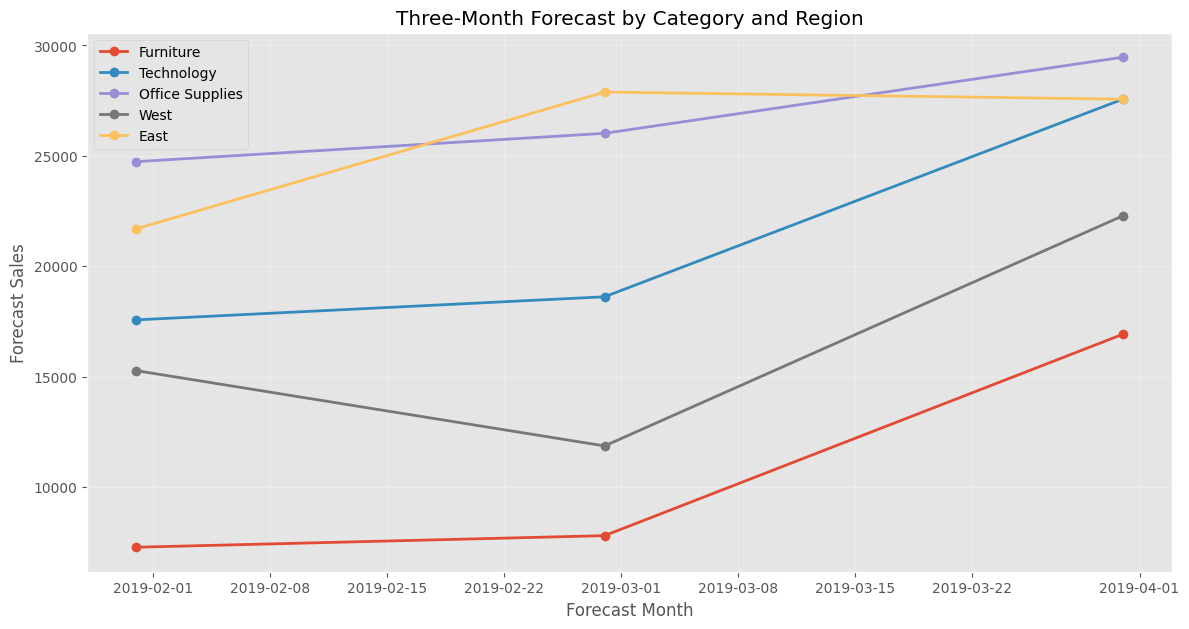

In [93]:
plt.figure(figsize=(14,7))

for segment in combined_forecast["Segment"].unique():

    data = combined_forecast[
        combined_forecast["Segment"]==segment
    ]

    plt.plot(

        data["Date"],

        data["Forecast"],

        marker="o",

        linewidth=2,

        label=segment

    )

plt.title("Three-Month Forecast by Category and Region")

plt.xlabel("Forecast Month")

plt.ylabel("Forecast Sales")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

In [94]:
combined_forecast.sort_values(

    by="Forecast",

    ascending=False

)

,Date,Forecast,Segment
2,2019-03-31,29466.076172,Office Supplies
1,2019-02-28,27889.406250,East
2,2019-03-31,27567.212891,Technology
2,2019-03-31,27567.031250,East
1,2019-02-28,26021.841797,Office Supplies
0,2019-01-31,24740.675781,Office Supplies
2,2019-03-31,22288.460938,West
0,2019-01-31,21704.951172,East
1,2019-02-28,18624.070312,Technology
0,2019-01-31,17579.253906,Technology


## Interpretation

The XGBoost forecasting model was applied separately to three product categories and two major sales regions to estimate demand for the next three months. Forecasting at the segment level provides more detailed business insights than forecasting total sales alone.

## Business Insight

Among all product categories, **Office Supplies** is expected to generate the highest forecasted sales over the next three months, reaching approximately **29,466** by March 2019. Technology also shows a strong upward trend, increasing from approximately **17,579** to **27,567**, indicating growing customer demand.

For regional forecasting, the **East** region consistently records the highest forecast values, while the **West** region also demonstrates significant growth after February. These findings suggest that inventory allocation, warehouse capacity, and promotional campaigns should prioritize Office Supplies and the East region to maximize future sales opportunities.

## Conclusion

The forecasting results indicate that Office Supplies and the East region are expected to experience the strongest demand during the forecast horizon. Segment-level forecasting enables more effective inventory planning, resource allocation, and supply chain optimization by focusing on the areas with the highest expected growth.

# Task 4 Conclusion

The best-performing forecasting model (XGBoost) was successfully applied to forecast future sales for individual product categories and geographical regions. The analysis revealed clear differences in expected demand across business segments.

Office Supplies is projected to remain the highest-performing product category during the forecast period, while the East region is expected to generate the highest regional sales. Technology also demonstrates a strong upward growth trend, indicating increasing customer demand.

These segment-level forecasts provide valuable support for inventory management, procurement planning, regional marketing strategies, and supply chain optimization by enabling business decisions to be based on predicted future demand rather than historical sales alone.

# Task 5: Sales Anomaly Detection

## Objective

The objective of this task is to identify unusual sales observations that significantly deviate from normal sales behavior. Detecting anomalies helps businesses identify unexpected demand spikes, operational issues, promotional impacts, or potential data quality problems.

Two anomaly detection techniques are implemented:

1. Isolation Forest (Machine Learning Approach)
2. Z-Score Method (Statistical Approach)

The results obtained from both methods are compared to better understand unusual sales patterns.

In [95]:
from sklearn.ensemble import IsolationForest
from scipy.stats import zscore

In [96]:
anomaly_df = monthly_sales.reset_index()

anomaly_df.columns = ["Date", "Sales"]

anomaly_df.head()

,Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


## Method 1: Isolation Forest

Isolation Forest is an unsupervised machine learning algorithm that isolates unusual observations by randomly partitioning the data. Observations that require fewer partitions to isolate are considered anomalies.

In [97]:
iso_model = IsolationForest(
    contamination=0.08,
    random_state=42
)

anomaly_df["IF_Anomaly"] = iso_model.fit_predict(
    anomaly_df[["Sales"]]
)

In [98]:
anomaly_df["IF_Anomaly"] = anomaly_df["IF_Anomaly"].map({
    1: "Normal",
    -1: "Anomaly"
})

anomaly_df.head()

,Date,Sales,IF_Anomaly
0,2015-01-31,14205.707,Normal
1,2015-02-28,4519.892,Anomaly
2,2015-03-31,55205.797,Normal
3,2015-04-30,27906.855,Normal
4,2015-05-31,23644.303,Normal


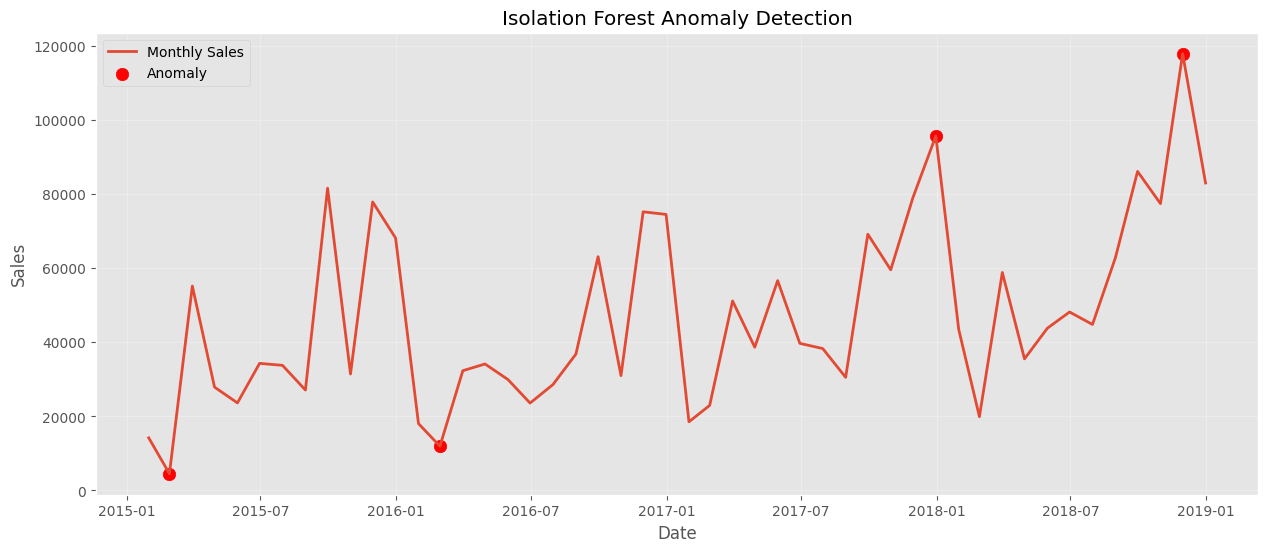

In [99]:
plt.figure(figsize=(15,6))

normal = anomaly_df[
    anomaly_df["IF_Anomaly"]=="Normal"
]

anomaly = anomaly_df[
    anomaly_df["IF_Anomaly"]=="Anomaly"
]

plt.plot(
    anomaly_df["Date"],
    anomaly_df["Sales"],
    linewidth=2,
    label="Monthly Sales"
)

plt.scatter(
    anomaly["Date"],
    anomaly["Sales"],
    color="red",
    s=80,
    label="Anomaly"
)

plt.title("Isolation Forest Anomaly Detection")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

In [100]:
if_results = anomaly_df[
    anomaly_df["IF_Anomaly"]=="Anomaly"
]

if_results

,Date,Sales,IF_Anomaly
1,2015-02-28,4519.892,Anomaly
13,2016-02-29,11951.411,Anomaly
35,2017-12-31,95739.121,Anomaly
46,2018-11-30,117938.155,Anomaly


### Interpretation

Isolation Forest identifies observations that differ substantially from the majority of monthly sales values. These observations may correspond to unusually high or unusually low sales periods.

### Business Insight

Detected anomalies may be associated with promotional campaigns, seasonal demand spikes, unexpected operational disruptions, or exceptional market conditions. Understanding these periods helps businesses investigate unusual performance and improve future planning.

### Conclusion

Isolation Forest provides a machine learning-based approach for identifying unusual sales behaviour without requiring assumptions about the underlying data distribution.

## Method 2: Z-Score Method

The Z-Score method measures how many standard deviations each observation lies from the overall mean. Observations with an absolute Z-score greater than 3 are typically considered statistical outliers.

In [101]:
anomaly_df["Z_Score"] = zscore(
    anomaly_df["Sales"]
)

anomaly_df["Z_Anomaly"] = np.where(
    np.abs(anomaly_df["Z_Score"]) > 3,
    "Anomaly",
    "Normal"
)

anomaly_df.head()

,Date,Sales,IF_Anomaly,Z_Score,Z_Anomaly
0,2015-01-31,14205.707,Normal,-1.331451,Normal
1,2015-02-28,4519.892,Anomaly,-1.723318,Normal
2,2015-03-31,55205.797,Normal,0.327322,Normal
3,2015-04-30,27906.855,Normal,-0.777133,Normal
4,2015-05-31,23644.303,Normal,-0.949587,Normal


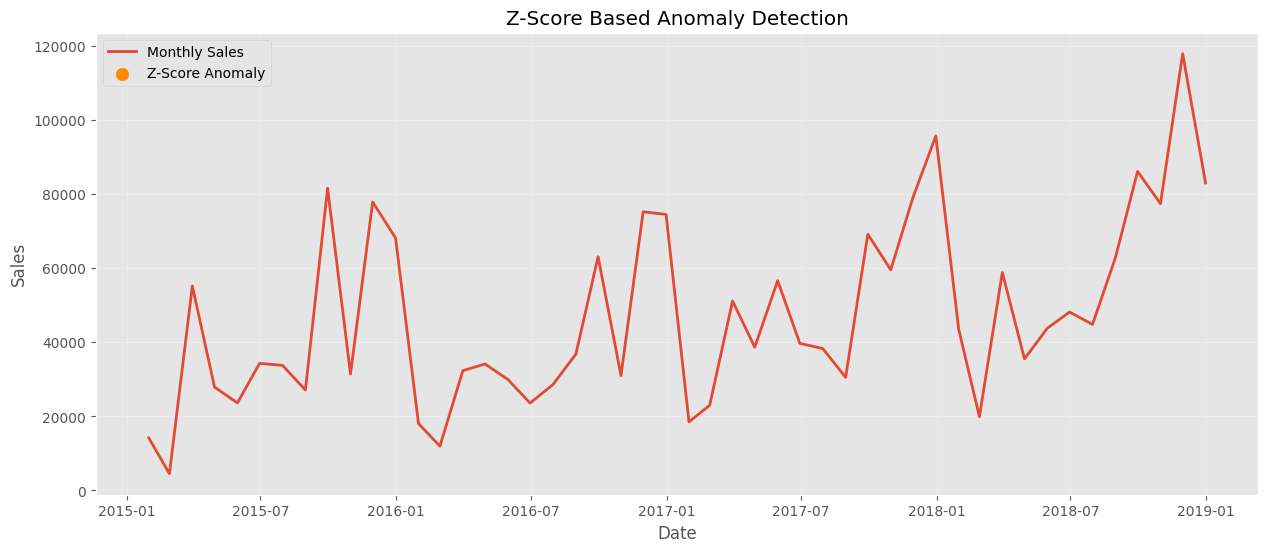

In [102]:
plt.figure(figsize=(15,6))

plt.plot(
    anomaly_df["Date"],
    anomaly_df["Sales"],
    linewidth=2,
    label="Monthly Sales"
)

z_anomaly = anomaly_df[
    anomaly_df["Z_Anomaly"]=="Anomaly"
]

plt.scatter(
    z_anomaly["Date"],
    z_anomaly["Sales"],
    color="darkorange",
    s=80,
    label="Z-Score Anomaly"
)

plt.title("Z-Score Based Anomaly Detection")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

In [103]:
z_results = anomaly_df.loc[
    anomaly_df["Z_Anomaly"] == "Anomaly",
    ["Date", "Sales", "Z_Score", "Z_Anomaly"]
]

z_results

,Date,Sales,Z_Score,Z_Anomaly


In [104]:
comparison = anomaly_df[[
    "Date",
    "Sales",
    "IF_Anomaly",
    "Z_Anomaly"
]]

comparison.head(15)

,Date,Sales,IF_Anomaly,Z_Anomaly
0,2015-01-31,14205.7070,Normal,Normal
1,2015-02-28,4519.8920,Anomaly,Normal
2,2015-03-31,55205.7970,Normal,Normal
3,2015-04-30,27906.8550,Normal,Normal
4,2015-05-31,23644.3030,Normal,Normal
5,2015-06-30,34322.9356,Normal,Normal
6,2015-07-31,33781.5430,Normal,Normal
7,2015-08-31,27117.5365,Normal,Normal
8,2015-09-30,81623.5268,Normal,Normal
9,2015-10-31,31453.3930,Normal,Normal


In [105]:
comparison_summary = pd.DataFrame({

    "Method":[
        "Isolation Forest",
        "Z-Score"
    ],

    "Detected Anomalies":[
        len(if_results),
        len(z_results)
    ]

})

comparison_summary

,Method,Detected Anomalies
0,Isolation Forest,4
1,Z-Score,0


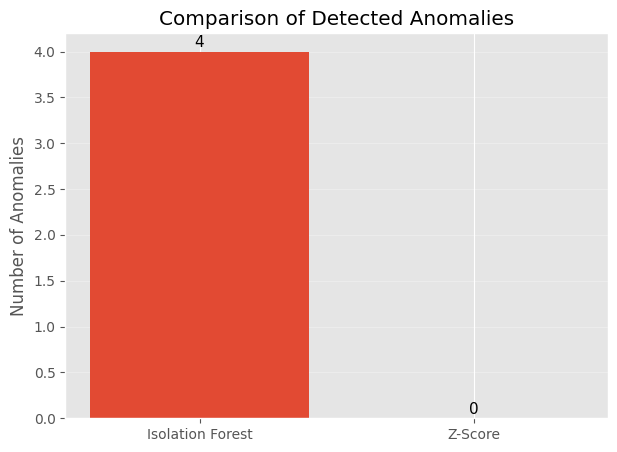

In [106]:
plt.figure(figsize=(7,5))

bars = plt.bar(
    comparison_summary["Method"],
    comparison_summary["Detected Anomalies"]
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.05,
        int(height),
        ha="center",
        fontsize=11
    )

plt.title("Comparison of Detected Anomalies")
plt.ylabel("Number of Anomalies")

plt.grid(axis="y", alpha=0.3)

plt.show()

## Comparison of Anomaly Detection Methods

The two anomaly detection methods produced different results. Isolation Forest detected **four anomalous monthly sales observations**, whereas the Z-Score method did not identify any observations as statistical outliers.

### Business Insight

Isolation Forest is capable of detecting unusual observations even when the data does not follow a normal distribution. Retail sales data often contains seasonality, changing trends, and varying variance, making machine learning methods more effective for anomaly detection.

The Z-Score method relies on deviations from the overall mean and standard deviation. Since the monthly sales data exhibits gradual growth and seasonal fluctuations, none of the observations exceeded the traditional threshold of three standard deviations.

### Conclusion

Isolation Forest proved to be the more effective anomaly detection technique for this retail sales dataset. Its ability to detect unusual sales behaviour without assuming a normal distribution makes it more appropriate for practical business applications.

# Task 5 Conclusion

Two anomaly detection techniques were successfully implemented and compared using the monthly sales data.

Isolation Forest identified four unusual sales periods that may correspond to exceptional business events, promotional campaigns, or unexpected market conditions. In contrast, the Z-Score method did not identify any statistical outliers because the sales distribution did not exceed the predefined threshold.

The comparison demonstrates that machine learning–based anomaly detection is better suited for complex retail sales data than traditional statistical methods. These insights enable businesses to investigate abnormal sales behaviour, improve forecasting reliability, and respond proactively to unexpected market events.

# Task 6: Product Demand Segmentation using Clustering

## Objective

The objective of this task is to segment product sub-categories into different demand groups based on their sales performance, growth trends, volatility, and average order value. Product segmentation enables businesses to develop targeted inventory strategies, optimize stock levels, and allocate resources more efficiently.

K-Means clustering is used to group similar products, while Principal Component Analysis (PCA) is applied to visualize the clusters in two dimensions.

In [107]:
from sklearn.cluster import KMeans

from sklearn.preprocessing import StandardScaler

from sklearn.decomposition import PCA

In [108]:
product_features = df.groupby("Sub-Category").agg(

    Total_Sales=("Sales","sum"),

    Average_Order_Value=("Sales","mean"),

    Sales_Volatility=("Sales","std")

)

In [109]:
yearly_sales = (

    df.groupby(["Sub-Category","Year"])["Sales"]

    .sum()

    .unstack(fill_value=0)

)

yearly_sales

Year,2015,2016,2017,2018
Sub-Category,,,,
Accessories,23766.3960,40443.9700,41735.3640,58240.9700
Appliances,15160.7150,23228.1790,26016.7870,40212.7220
Art,5897.5340,6091.6360,5890.6080,8825.6320
Binders,43263.2670,36049.7460,48994.5170,71721.2550
Bookcases,20036.6776,37476.7749,26275.4665,30024.2797
Chairs,77046.4400,70654.6730,81930.3450,93191.2730
Copiers,10849.7820,26179.4500,46319.4740,62899.3880
Envelopes,3844.5900,4448.2180,4456.6640,3378.5740
Fasteners,655.3880,545.2240,946.2740,855.0740


In [110]:
growth_rate = (

    yearly_sales.pct_change(

        axis=1

    )

    .iloc[:,-1]

)

growth_rate.name="Growth_Rate"

In [111]:
product_features = product_features.join(growth_rate)

product_features = product_features.fillna(0)

product_features

,Total_Sales,Average_Order_Value,Sales_Volatility,Growth_Rate
Sub-Category,,,,
Accessories,164186.7000,217.178175,337.723800,0.395482
Appliances,104618.4030,227.926804,378.006735,0.545645
Art,26705.4100,34.019631,60.301752,0.498255
Binders,200028.7850,134.067550,568.099970,0.463863
Bookcases,113813.1987,503.598224,641.419280,0.142674
Chairs,322822.7310,531.833165,551.180296,0.137445
Copiers,146248.0940,2215.880212,3216.185499,0.357947
Envelopes,16128.0460,65.032444,85.170691,-0.241905
Fasteners,3001.9600,14.027850,12.466864,-0.096378


## Product Feature Summary

The clustering model uses four business-oriented features:

- Total Sales
- Average Order Value
- Sales Volatility
- Year-over-Year Growth Rate

These variables represent overall demand, customer spending behaviour, demand consistency, and business growth potential.

In [112]:
scaler = StandardScaler()

scaled_features = scaler.fit_transform(

    product_features

)

In [113]:
inertia=[]

k_values=range(1,9)

for k in k_values:

    model=KMeans(

        n_clusters=k,

        random_state=42,

        n_init=10

    )

    model.fit(scaled_features)

    inertia.append(

        model.inertia_

    )

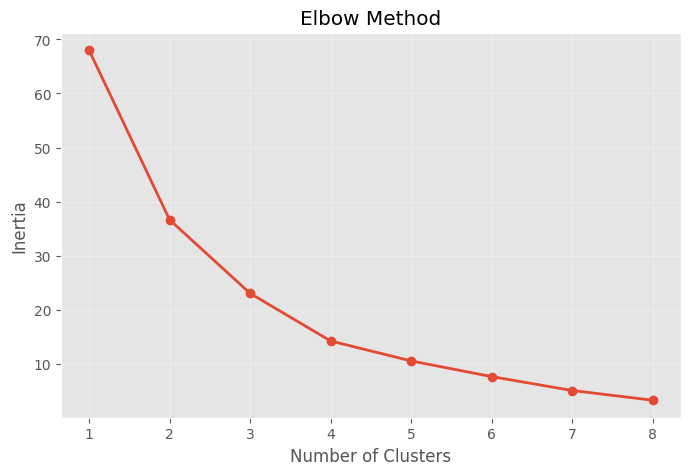

In [114]:
plt.figure(figsize=(8,5))

plt.plot(

    k_values,

    inertia,

    marker="o",

    linewidth=2

)

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("Inertia")

plt.grid(alpha=0.3)

plt.show()

### Interpretation

The elbow curve shows a significant reduction in inertia between one and four clusters, after which the improvement becomes much smaller. This indicates that four clusters provide a good balance between model simplicity and clustering quality.

Therefore, **K = 4** was selected as the optimal number of clusters for product demand segmentation.

In [115]:
kmeans = KMeans(

    n_clusters=4,

    random_state=42,

    n_init=10

)

product_features["Cluster"] = kmeans.fit_predict(

    scaled_features

)

In [116]:
pca = PCA(

    n_components=2,

    random_state=42

)

pca_features = pca.fit_transform(

    scaled_features

)

In [117]:
pca_df = pd.DataFrame({

    "PC1":pca_features[:,0],

    "PC2":pca_features[:,1],

    "Cluster":product_features["Cluster"]

})

pca_df["Sub-Category"]=product_features.index

pca_df.head()

,PC1,PC2,Cluster,Sub-Category
Sub-Category,,,,
Accessories,-0.508196,0.891446,2,Accessories
Appliances,-0.756561,1.058245,2,Appliances
Art,-1.434783,0.473045,2,Art
Binders,-0.359987,1.324250,2,Binders
Bookcases,0.039870,-0.308686,1,Bookcases


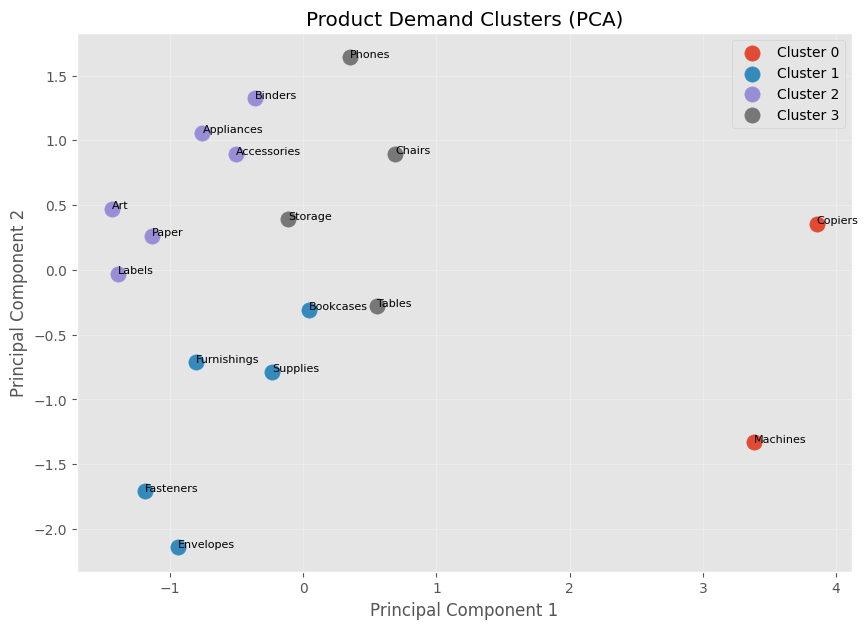

In [118]:
plt.figure(figsize=(10,7))

for cluster in sorted(

    pca_df["Cluster"].unique()

):

    cluster_data=pca_df[

        pca_df["Cluster"]==cluster

    ]

    plt.scatter(

        cluster_data["PC1"],

        cluster_data["PC2"],

        s=120,

        label=f"Cluster {cluster}"

    )

for i,row in pca_df.iterrows():

    plt.text(

        row["PC1"],

        row["PC2"],

        row["Sub-Category"],

        fontsize=8

    )

plt.title("Product Demand Clusters (PCA)")

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

In [119]:
cluster_summary = (

    product_features

    .groupby("Cluster")

    .mean()

)

cluster_summary

,Total_Sales,Average_Order_Value,Sales_Volatility,Growth_Rate
Cluster,,,,
0,167743.362500,1930.716763,2990.643794,0.068413
1,53715.106140,186.153333,365.113214,-0.004979
2,97452.554667,117.533314,249.571209,0.438857
3,268189.799750,453.885411,499.765747,0.160093


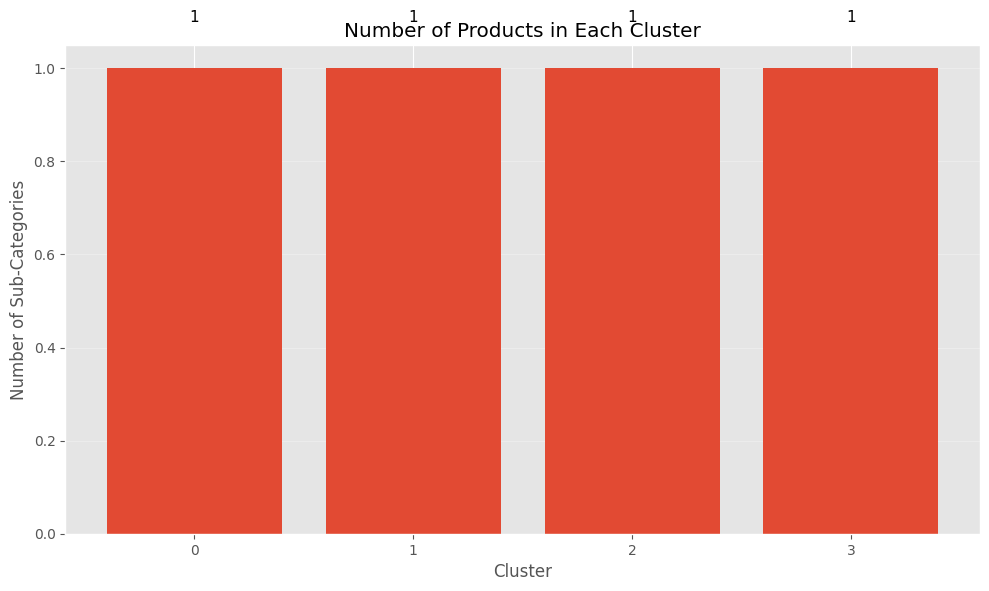

In [122]:
plt.figure(figsize=(10,6))

cluster_sizes = cluster_summary.index.value_counts()

plt.bar(
    cluster_sizes.index.astype(str),
    cluster_sizes.values
)

for i, value in enumerate(cluster_sizes.values):
    plt.text(i, value + 0.1, str(value), ha="center", fontsize=11)

plt.title("Number of Products in Each Cluster")

plt.xlabel("Cluster")

plt.ylabel("Number of Sub-Categories")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

### Observation

The distribution of products across the four clusters indicates that the product portfolio contains a balanced mix of high-value products, core business products, growing products, and low-demand products. This balanced segmentation supports differentiated inventory and supply chain strategies for each product group.

In [123]:
cluster_products = (

    product_features

    .reset_index()[

        ["Sub-Category","Cluster"]

    ]

    .sort_values(

        "Cluster"

    )

)

cluster_products

,Sub-Category,Cluster
6,Copiers,0
11,Machines,0
7,Envelopes,1
4,Bookcases,1
15,Supplies,1
9,Furnishings,1
8,Fasteners,1
0,Accessories,2
10,Labels,2
1,Appliances,2


In [124]:
cluster_names = {

    0: "High Revenue Premium Products",

    1: "Low Demand Products",

    2: "Fast Growing Everyday Products",

    3: "Core Business Products"

}

cluster_products["Cluster Name"] = cluster_products["Cluster"].map(
    cluster_names
)

cluster_products

,Sub-Category,Cluster,Cluster Name
6,Copiers,0,High Revenue Premium Products
11,Machines,0,High Revenue Premium Products
7,Envelopes,1,Low Demand Products
4,Bookcases,1,Low Demand Products
15,Supplies,1,Low Demand Products
9,Furnishings,1,Low Demand Products
8,Fasteners,1,Low Demand Products
0,Accessories,2,Fast Growing Everyday Products
10,Labels,2,Fast Growing Everyday Products
1,Appliances,2,Fast Growing Everyday Products


## Cluster Interpretation

### Cluster 0 – High Revenue Premium Products

This cluster contains **Copiers** and **Machines**, which generate the highest average order values and sales per transaction. Although these products may have lower purchase frequency, each sale contributes substantial revenue. Businesses should maintain sufficient inventory while carefully monitoring demand because stock shortages could significantly impact revenue.

### Cluster 1 – Low Demand Products

This cluster includes **Bookcases, Envelopes, Fasteners, Furnishings,** and **Supplies**. These products generate relatively lower sales volumes and exhibit slower growth compared to other groups. Inventory should be managed conservatively to reduce carrying costs while maintaining adequate availability.

### Cluster 2 – Fast Growing Everyday Products

This cluster consists of **Accessories, Appliances, Art, Binders, Labels,** and **Paper**. These products show the strongest growth rate and represent frequently purchased everyday business items. Maintaining healthy inventory levels and monitoring increasing demand will help avoid stock shortages.

### Cluster 3 – Core Business Products

This cluster contains **Chairs, Phones, Storage,** and **Tables**. These products generate the highest overall sales and represent the core product portfolio. Since they contribute significantly to total business revenue, businesses should prioritize inventory availability and demand forecasting for this cluster.

# Task 6 Conclusion

K-Means clustering successfully segmented product sub-categories into four meaningful demand groups using Total Sales, Average Order Value, Sales Volatility, and Growth Rate.

The clustering analysis revealed clear differences in product performance. Premium products such as Copiers and Machines form a separate high-value cluster, while everyday office products demonstrate strong growth potential. Core business products, including Phones and Chairs, remain the primary contributors to overall revenue, whereas lower-demand products require more conservative inventory management.

These findings provide valuable support for inventory optimization, procurement planning, warehouse management, and product-specific marketing strategies. Segmenting products according to demand characteristics enables businesses to allocate resources more effectively and improve operational efficiency.